# TrueML Challenge

The following project is about a challenge to predict the propensity to make a payment on a debt.
Through the notebook there will be explanations that are given in order to understand each step. The goal of this project is to understand the behavoir of the data so that a Machine Learning model can be built and make the predictions.
Several methodos were applied in this project:
* creation of plots to understand data
* creation of functions for a more general process
* A/B testing using Kolmogorov-Smirnov for numerical data test and Chi2 for categorical data

Developing of a ML model which includes methods of 

* Feature Selection
* Feature Engineering
* model selection
* cross validation
* model tracking using MLflow 
* model interpretation.


In [400]:
# Let's start by importing the minimal libraries that we will use
# but more libraries are going to be considered through the notebook 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.stats as stats
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from category_encoders.woe import WOEEncoder

In [ ]:

# Let's load our dataset named debt_sample
df = pd.read_csv('debt_sample.csv')

# Let's start by getting some basic information of the dataset, since it's important to get familiar with it
print('Shape of the dataset:', df.shape)


Shape of the dataset: (671, 16)


In [ ]:
# Let's have a quick look at the dataset

df.head()

,account_id,made_last_payment_on_time,latest_communication_channel,minimum_payment,previous_payment_amount,product,last_reminder_sent_days,debt_to_income_ratio,opened_last_communication,used_chat_feature,count_comms_sent_last_30d,homeowner,ever_missed_payment,age_of_debt_yrs,total_balance,latest_communication_dow
0,0,0,Email,22.0,3.58,Credit Card,9,1.210,0,1,0,1,1,1.00,1213.00,Monday
1,1,0,SMS,23.0,3.00,Credit Card,8,2.415,0,0,0,0,1,1.60,44.48,Monday
2,2,0,SMS,30.0,8.08,Deferred Repayment,11,5.000,0,0,0,1,1,2.80,58.04,Monday
3,3,1,SMS,22.0,12.42,Deferred Repayment,4,0.165,1,1,6,1,1,0.08,42.52,Friday
4,4,1,Email,20.0,19.00,Credit Card,8,1.500,1,0,0,0,1,0.60,159.00,Monday


In [ ]:
# It's always a good idea to get to know the type of each column in the dataset
# and at the same time we will know whether we have missing data

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   account_id                    671 non-null    int64  
 1   made_last_payment_on_time     671 non-null    int64  
 2   latest_communication_channel  671 non-null    str    
 3   minimum_payment               671 non-null    float64
 4   previous_payment_amount       671 non-null    float64
 5   product                       671 non-null    str    
 6   last_reminder_sent_days       671 non-null    int64  
 7   debt_to_income_ratio          671 non-null    float64
 8   opened_last_communication     671 non-null    int64  
 9   used_chat_feature             671 non-null    int64  
 10  count_comms_sent_last_30d     671 non-null    int64  
 11  homeowner                     671 non-null    int64  
 12  ever_missed_payment           671 non-null    int64  
 13  age_of_debt_yrs 

As we can see, there is not any missing value.

In [ ]:
# to have a starting idea of the behavoir of the data, let's use describe which retrieves basic statistics

df.describe()

,account_id,made_last_payment_on_time,minimum_payment,previous_payment_amount,last_reminder_sent_days,debt_to_income_ratio,opened_last_communication,used_chat_feature,count_comms_sent_last_30d,homeowner,ever_missed_payment,age_of_debt_yrs,total_balance
count,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,6.710000e+02
mean,344.441133,0.444113,31.640835,10.018614,7.459016,2.293845,0.532042,0.423249,2.323398,0.467958,0.804769,1.872981,1.583436e+04
std,198.875673,0.497238,11.779215,10.344544,3.720581,3.476073,0.499344,0.494443,4.661180,0.499344,0.396674,1.714781,3.860307e+05
min,0.000000,0.000000,14.000000,0.080000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080000,1.900000e+01
25%,173.500000,0.000000,23.000000,2.250000,4.000000,0.165000,0.000000,0.000000,0.000000,0.000000,1.000000,0.800000,5.092500e+01
50%,344.000000,0.000000,29.000000,6.000000,8.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.600000,7.913000e+01
75%,516.500000,1.000000,38.000000,15.165000,10.500000,2.750000,1.000000,1.000000,2.000000,1.000000,1.000000,2.780000,4.450000e+02
max,689.000000,1.000000,80.000000,56.000000,14.000000,28.500000,1.000000,1.000000,60.000000,1.000000,1.000000,20.000000,1.000010e+07


In [103]:
# Since account_id is a unique identifier for each row, we can drop it from the dataset as it won't be useful for our analysis.
df = df.drop('account_id', axis=1)

In [ ]:
# As we will see, it's important to idendify our categorical and numerical data. Firts we get our categorical data

categorical_data = list(df.select_dtypes(include=['object']).columns)
categorical_data

C:\Users\cleme\AppData\Local\Temp\ipykernel_4660\327026747.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_data = list(df.select_dtypes(include=['object']).columns)


['latest_communication_channel', 'product', 'latest_communication_dow']

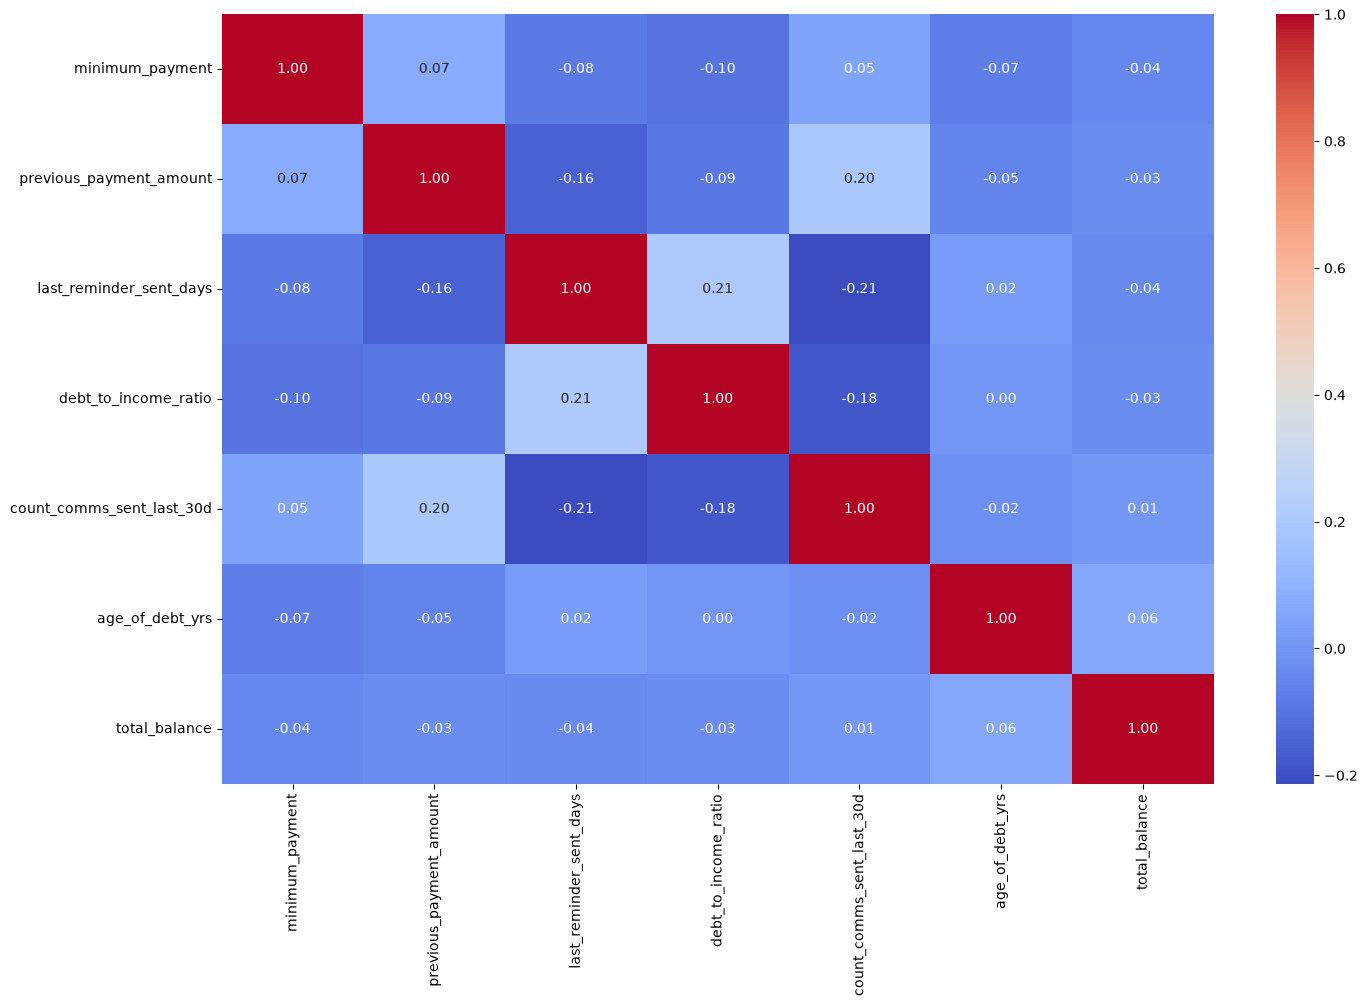

In [ ]:
# Let's study the linear relationship between the variables and the target variable


# Let's now gather the names of our numerical variables
not_categorical = [x for x in df.columns if df[x].dtype in ['int64', 'float64']]

# Since 'made_last_payment_on_time', 'opened_last_communication', 'used_chat_feature', 'ever_missed_payment', 'homeowner'
# are binary variables, we will not include them in the correlation matrix as they are not suitable for correlation analysis.

not_for_corr = ['made_last_payment_on_time', 'opened_last_communication', 'used_chat_feature', 'ever_missed_payment', 'homeowner']


# now let's plot a heatmap which has the information of the correlation between the numerical variables
# This is done to check whethere there is multicollinearity among the input variables.
# Since our target variable (made_last_payment_on_time) is binary, we can not include it in this plot

plt.figure(figsize=(16, 10))
sns.heatmap(df[not_categorical].drop(not_for_corr, axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

Let's remember that one of the assumptions of linearity is that there shouldn't exist multicollinearity between the independent variables.
Then, by not finding any strong correlation between them, we can´t still discard a linear nature

In [ ]:
# since our goal is to build a ML model, it's important to consider the cardinality of our categorical data
# that can be eassily done using value_counts
for i in not_for_corr:
    print(df[i].value_counts())
    print()

made_last_payment_on_time
0    373
1    298
Name: count, dtype: int64

opened_last_communication
1    357
0    314
Name: count, dtype: int64

used_chat_feature
0    387
1    284
Name: count, dtype: int64

ever_missed_payment
1    540
0    131
Name: count, dtype: int64

homeowner
0    357
1    314
Name: count, dtype: int64



In [ ]:

# With this function, we can study th the behavoir of the variables: histogram (to study distributions), Q-Q plots to study
# linearity of the variables and boxplots to study mainly outliers

def diagnostic_plots(df, variable):
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # Q-Q plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

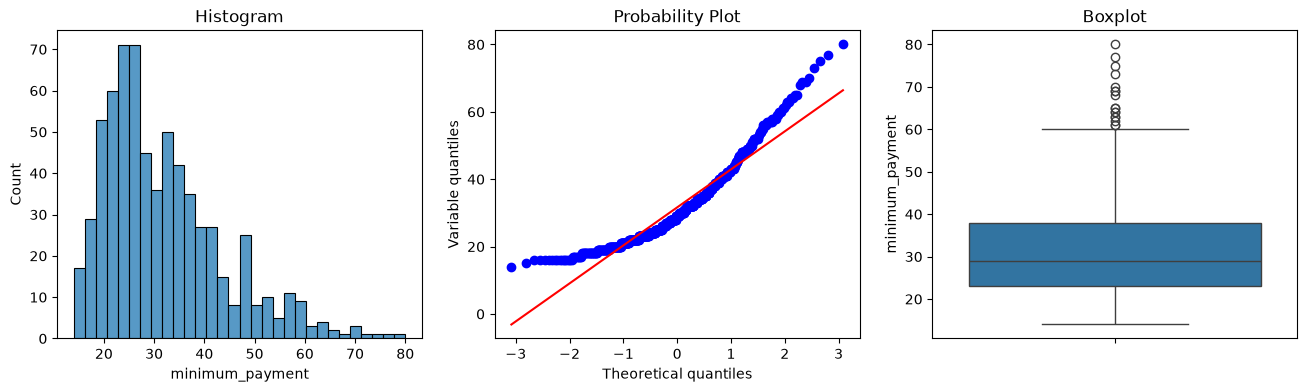

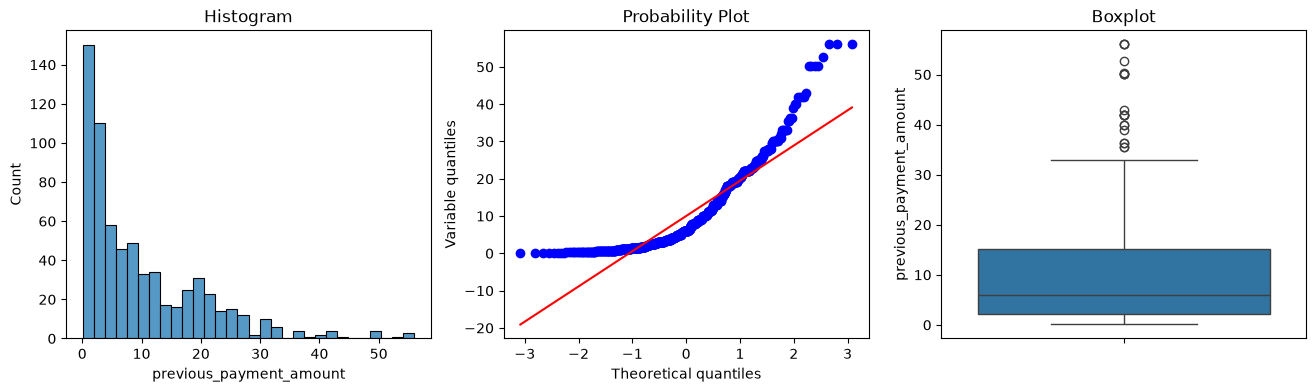

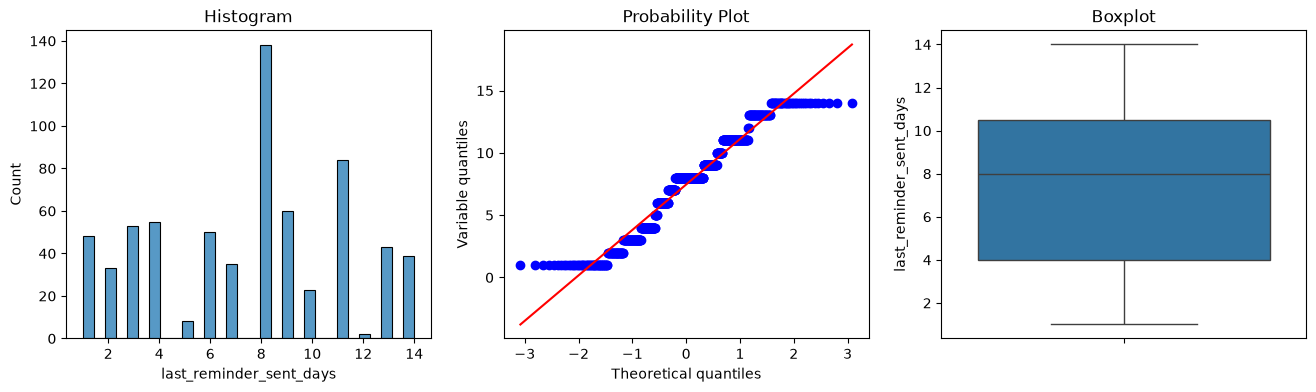

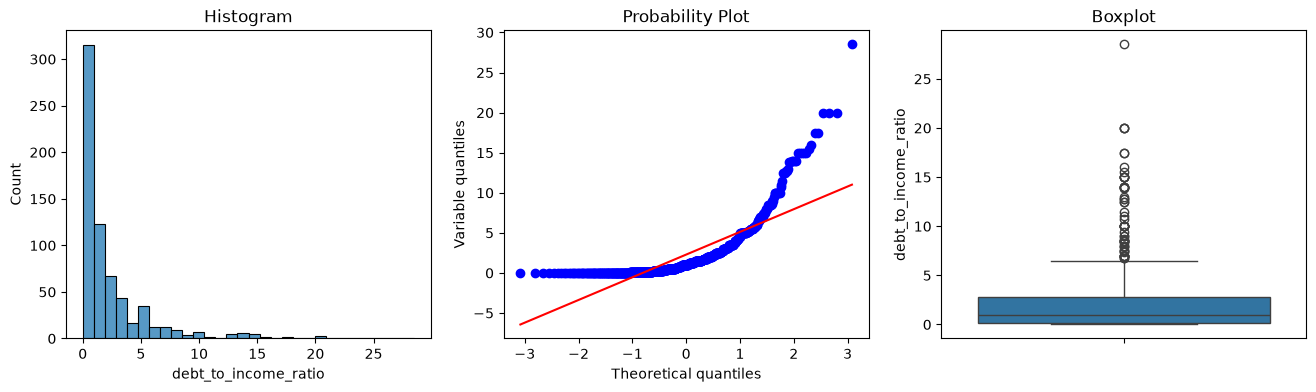

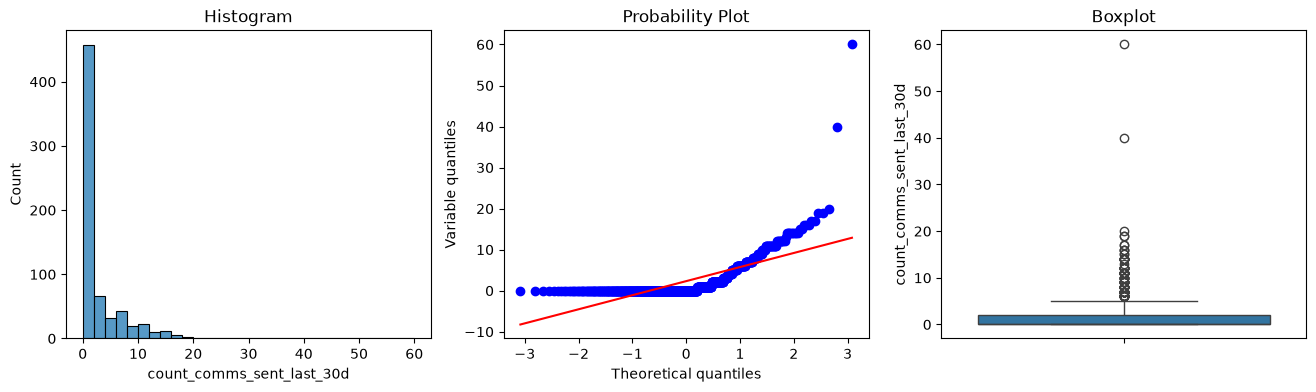

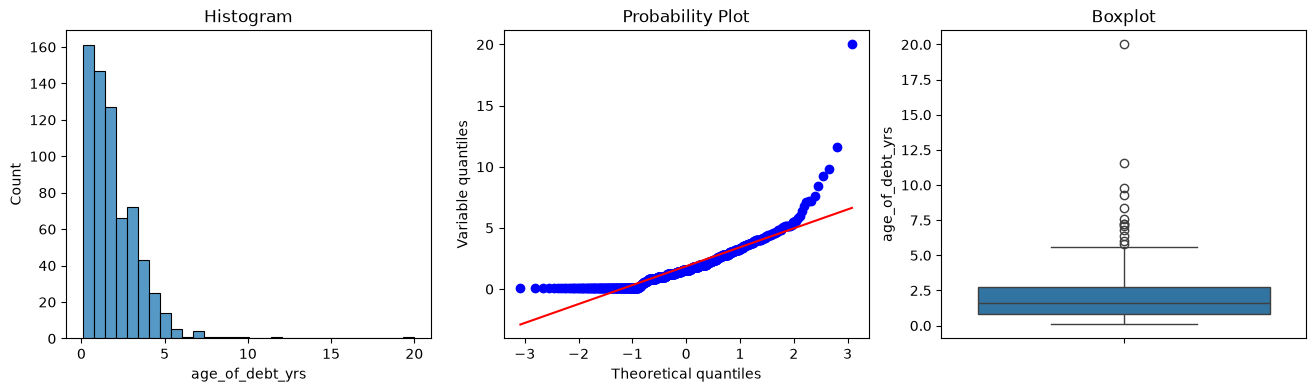

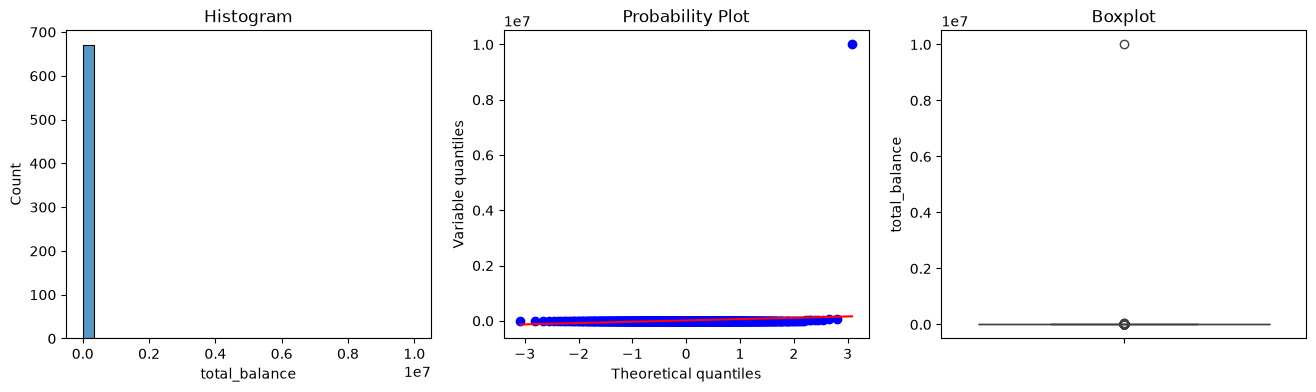

In [ ]:
# Let's applied a general analysis before going deeper, again disregarding (by now) the categorical variables and
# binary variables


for i in df[not_categorical].drop(not_for_corr, axis=1).columns:
    diagnostic_plots(df[not_categorical].drop(not_for_corr, axis=1), i)

Let's start by noticing that all the data seems to be skewed to the right. This is important because it lets us see that there is a common behavior in the numerical data. Let's see if we can find a similar situation by taking the data when made_last_payment_on_time is 1 or 0:

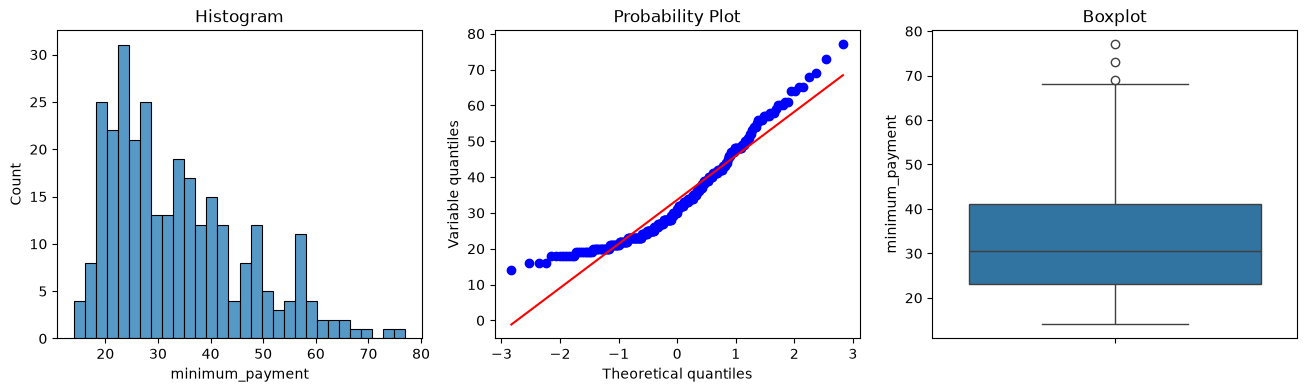

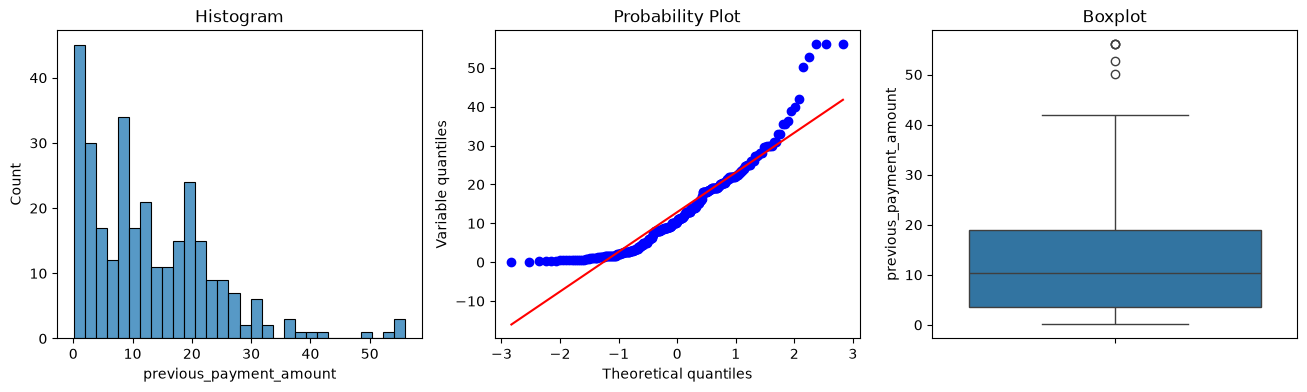

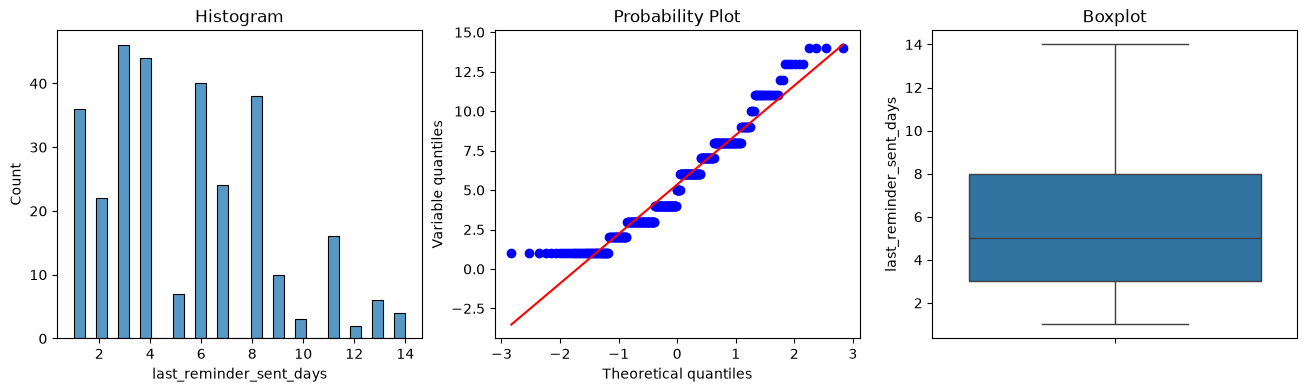

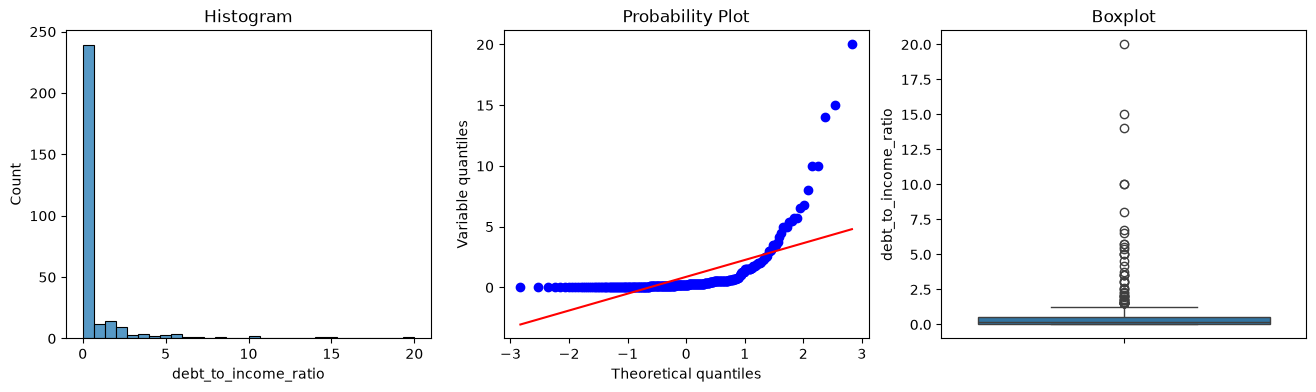

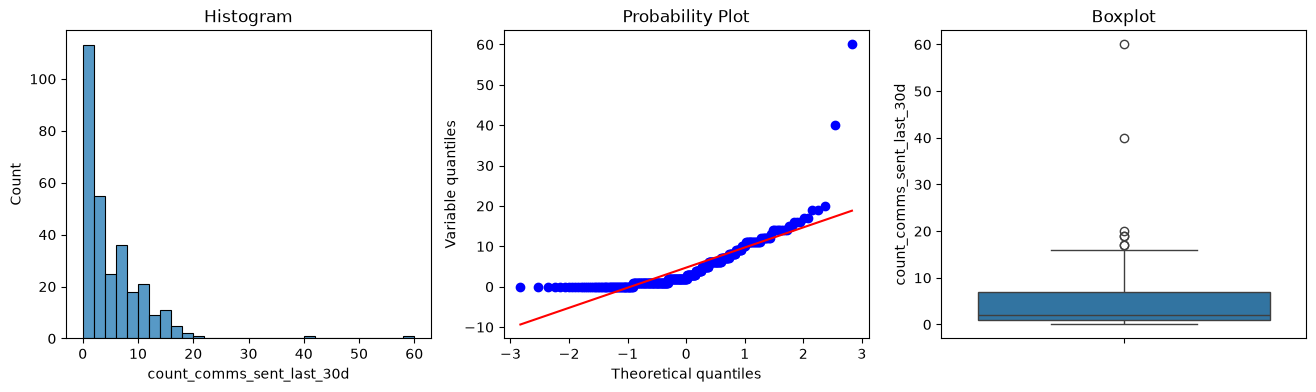

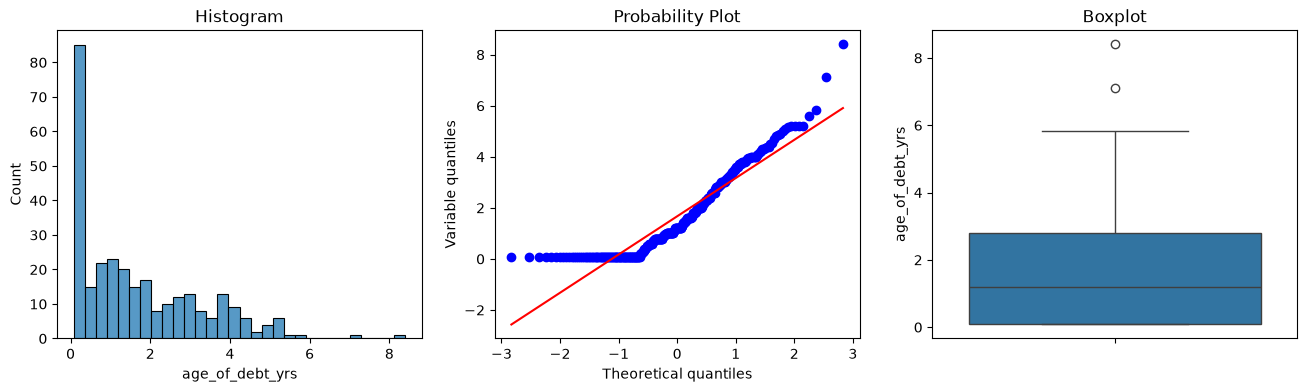

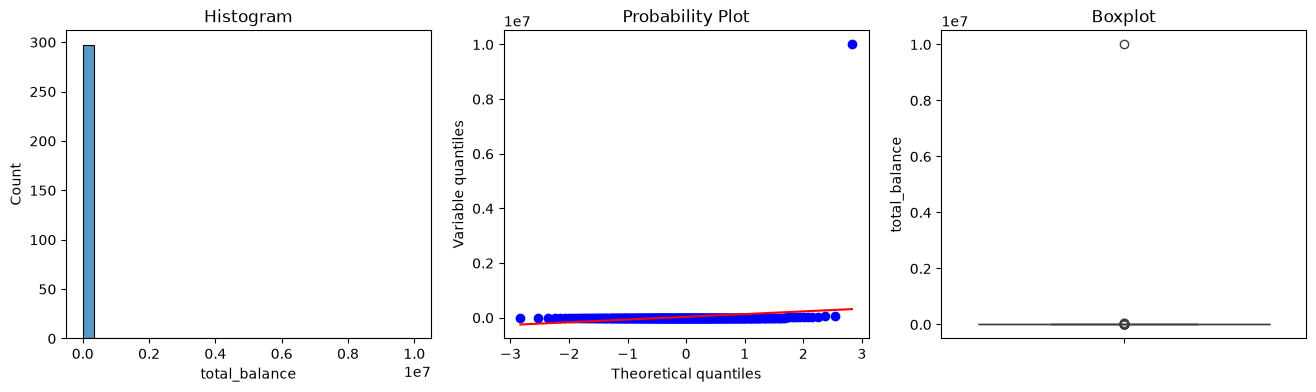

In [ ]:
one_df = df[df['made_last_payment_on_time']==1]
zero_df = df[df['made_last_payment_on_time']==0]

# Let's plot firts when made_last_payment_on_time = 1

for i in one_df[not_categorical].drop(not_for_corr, axis=1).columns:
    diagnostic_plots(one_df[not_categorical].drop(not_for_corr, axis=1), i)

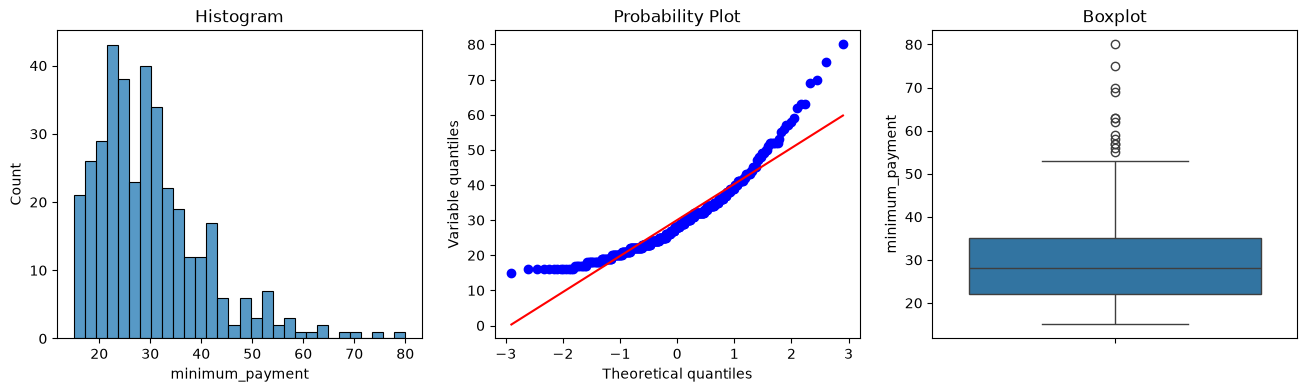

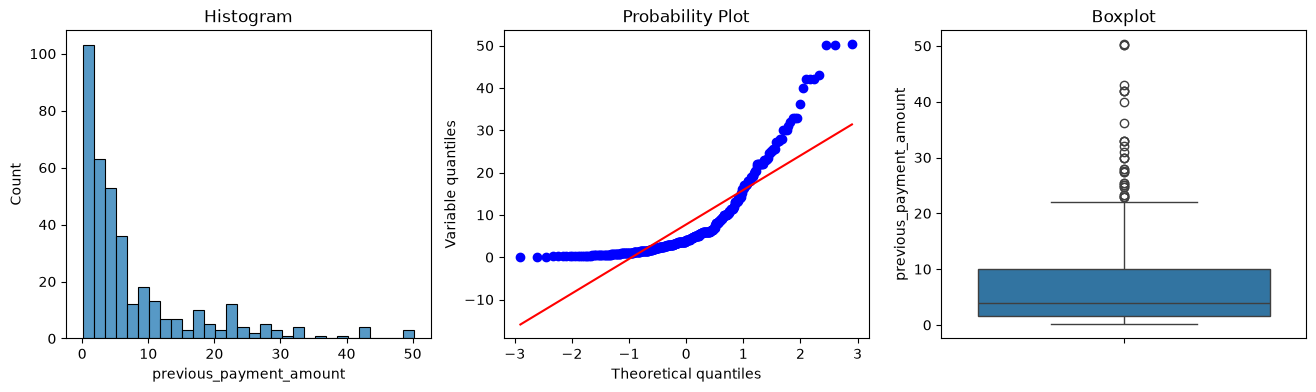

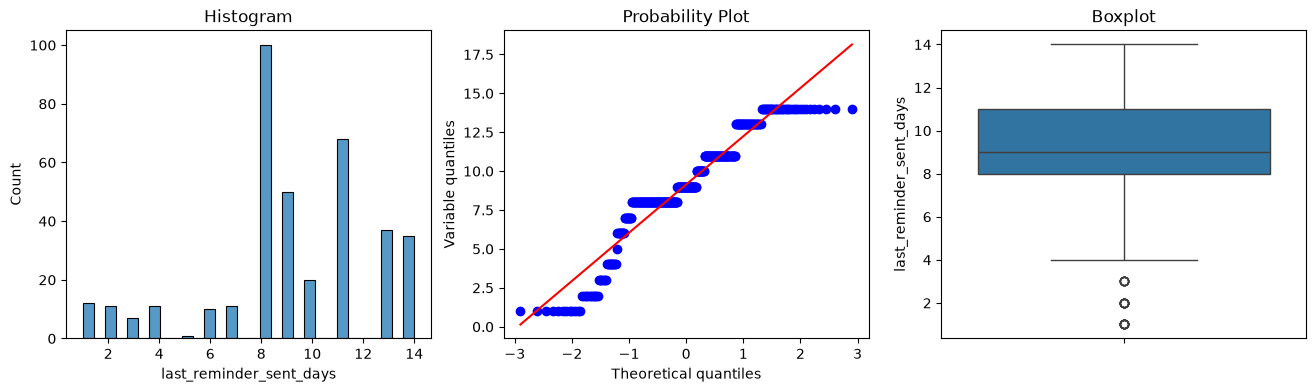

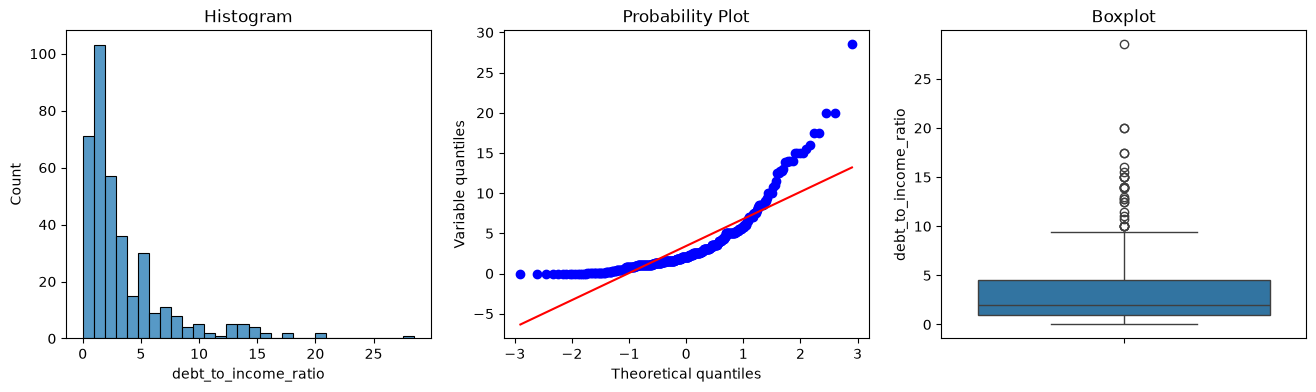

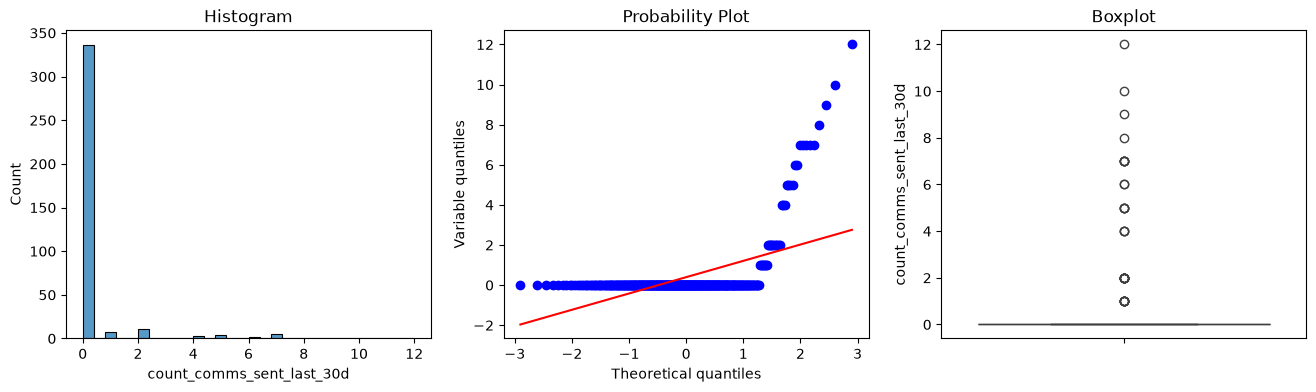

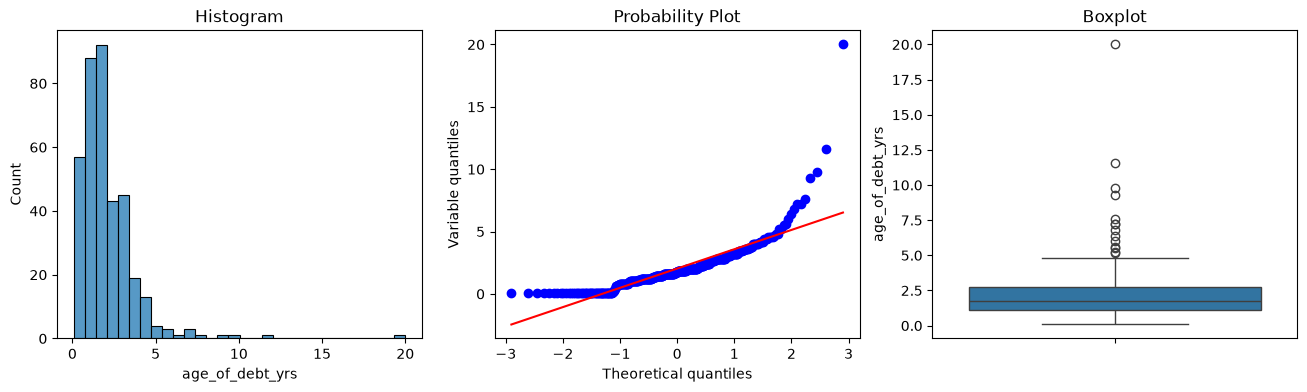

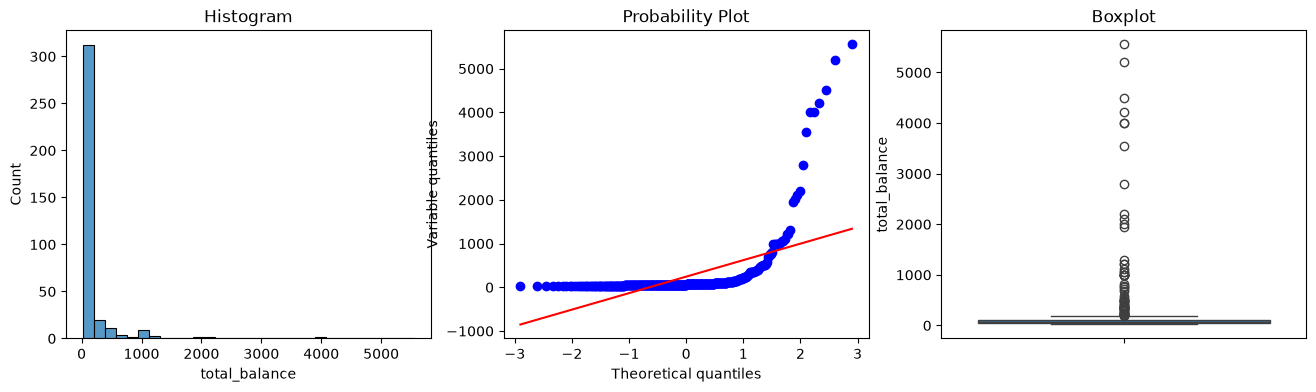

In [404]:
# Let's now check when # Let's plot firts when made_last_payment_on_time = 0

for i in zero_df[not_categorical].drop(not_for_corr, axis=1).columns:
    diagnostic_plots(zero_df[not_categorical].drop(not_for_corr, axis=1), i)

We can see that the behavoior of the data keeps happening even when we divide the cases when made_last_payment_on_time is 1 or 0

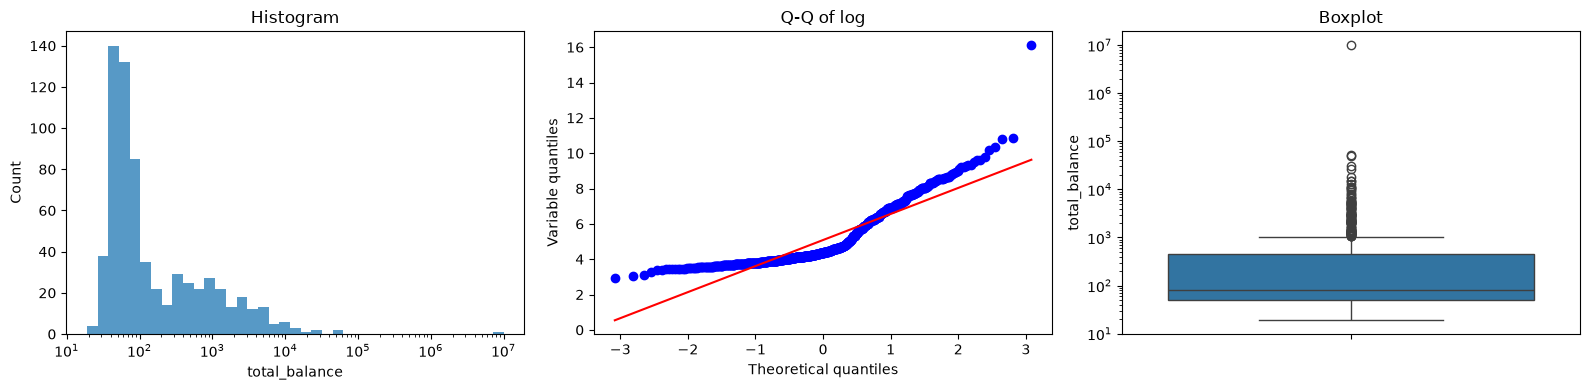

In [ ]:
#Something that we must notice is that the magnitude of total_balance does not allow us to have better look
# at its behvaior, then let's try to make the variable smoother by applying a log


x = df['total_balance']           

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram for log(x)
bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40)
sns.histplot(x, bins=bins, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Histogram')

# Q-Q over log(x)
stats.probplot(np.log(x), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q of log')
axes[1].set_ylabel('Variable quantiles')

# Boxplot 
sns.boxplot(y=x, ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('Boxplot')

plt.tight_layout()

Again, let's notice how this variable is skewed to the right just as well as the rest of the numerical variables

# Let's study the behavoir of the variables depending on the kind of product

As we will see, when we now take the cases for each product, data changes a little

Diagnostic plots for product: Credit Card


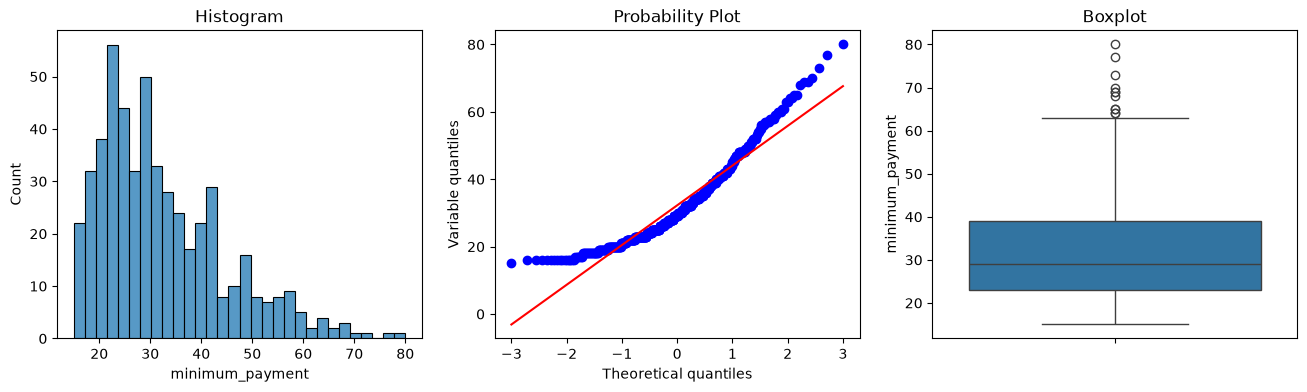

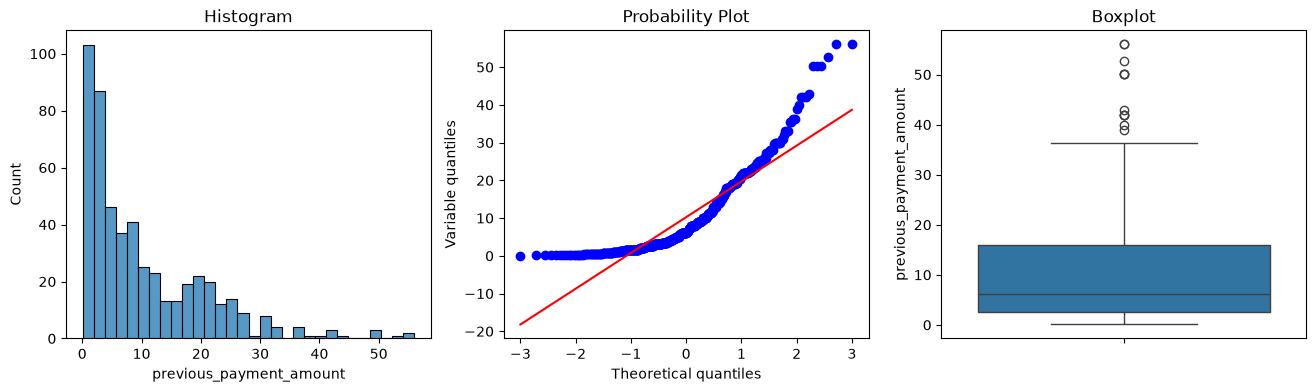

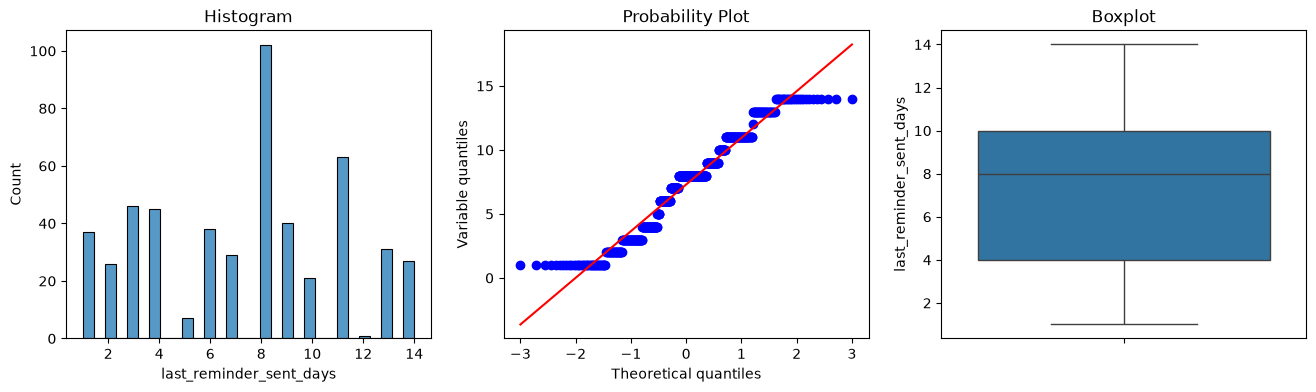

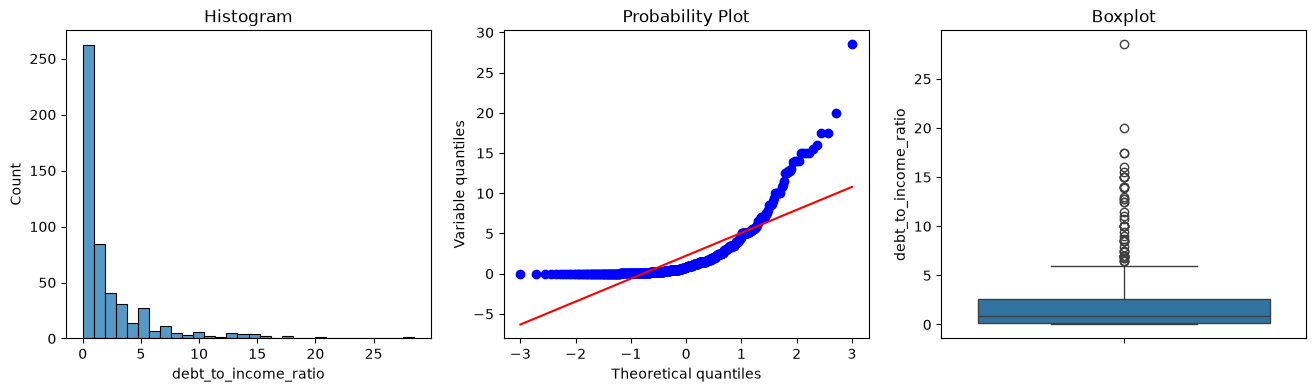

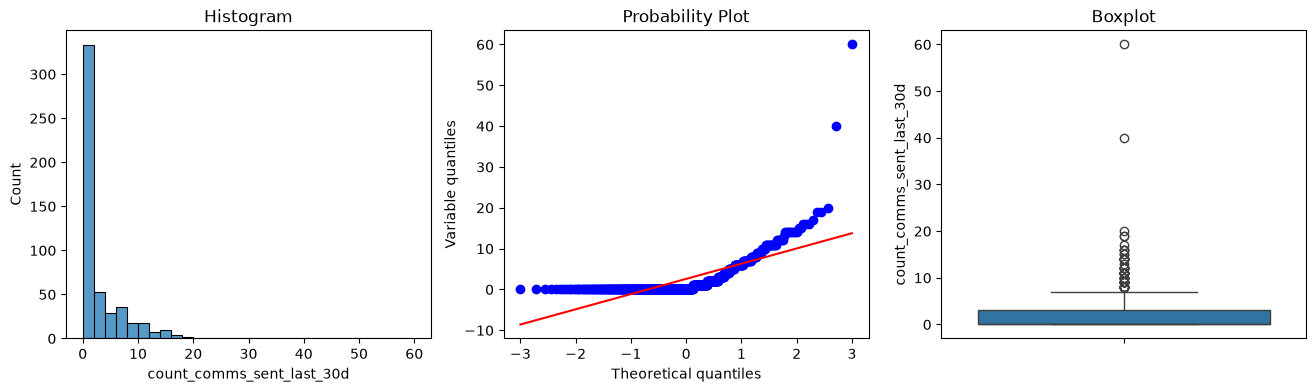

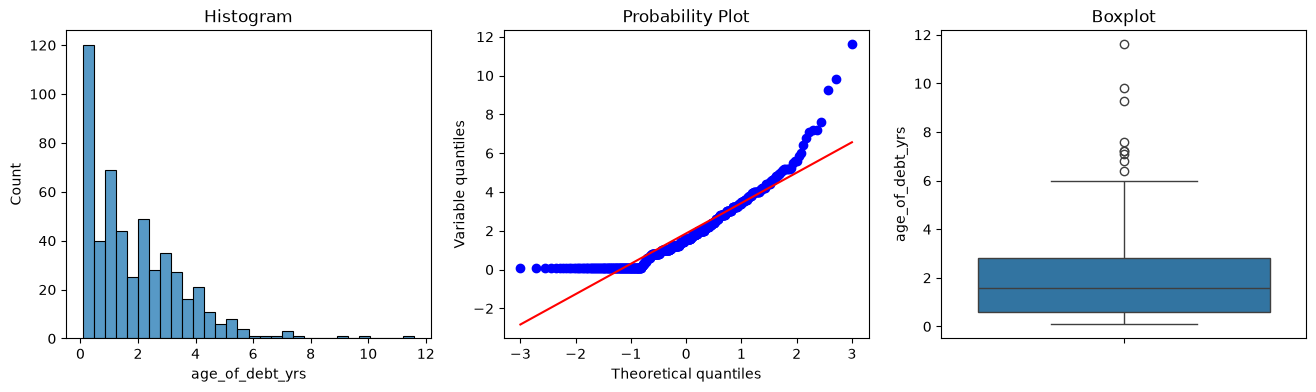

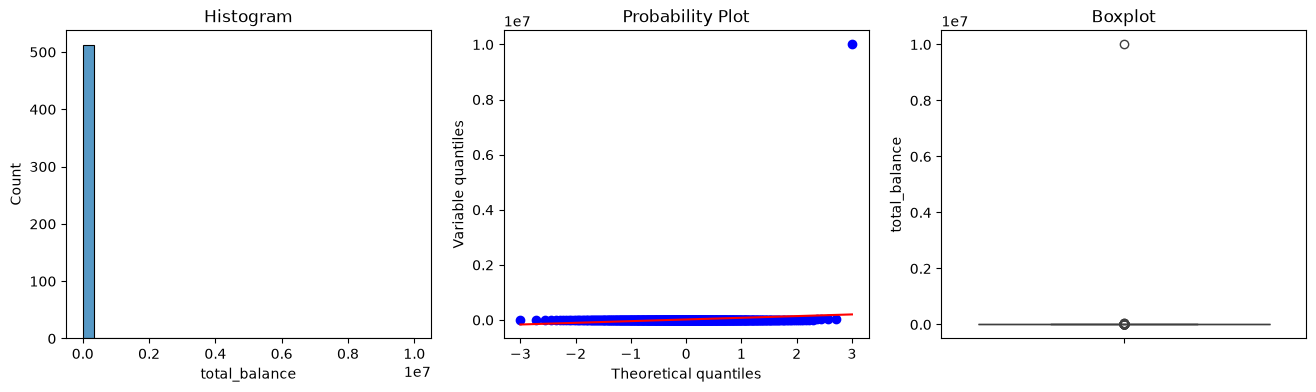

Diagnostic plots for product: Deferred Repayment


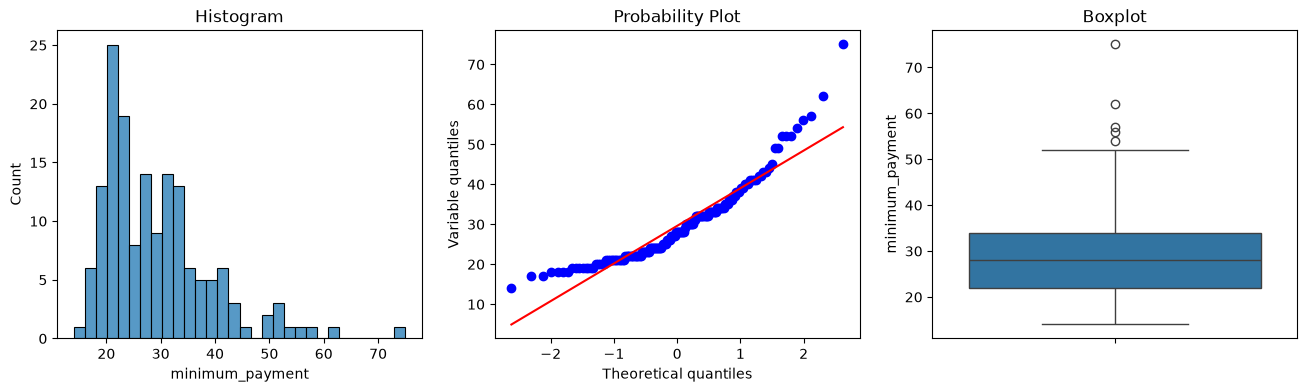

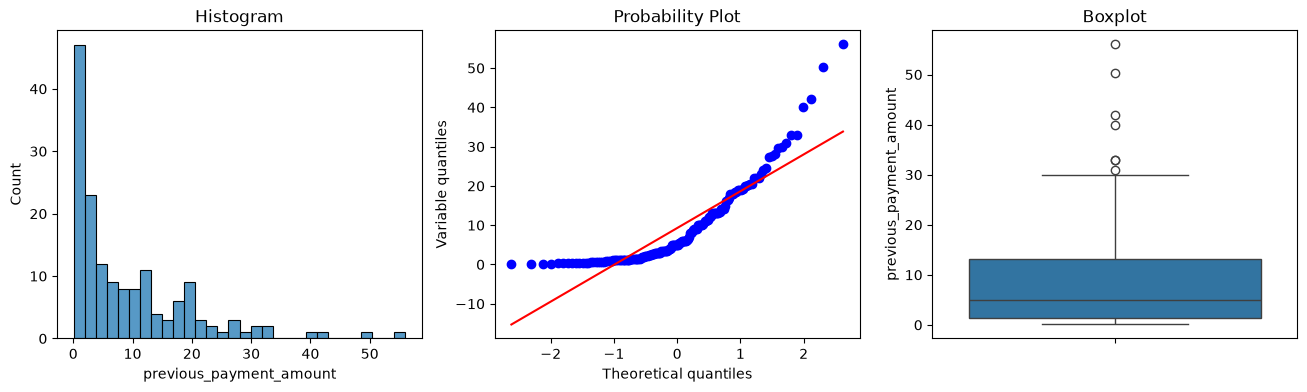

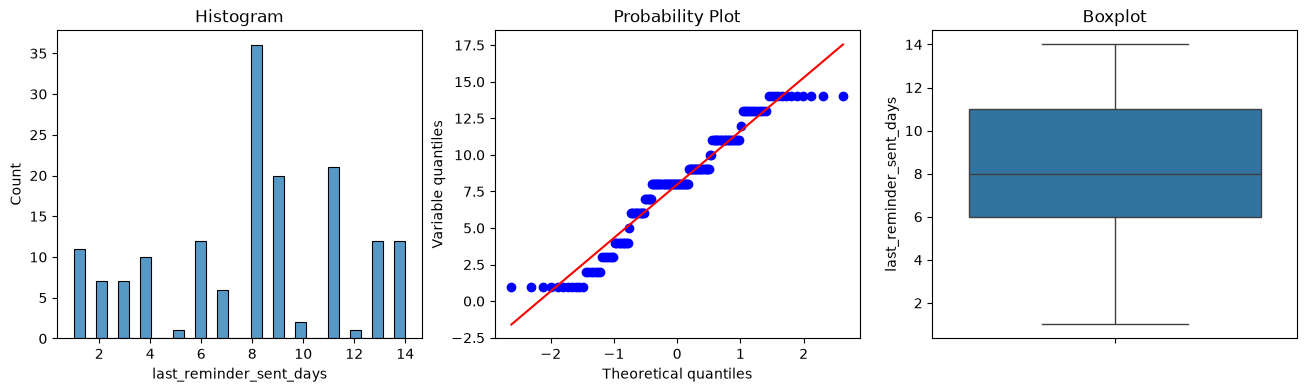

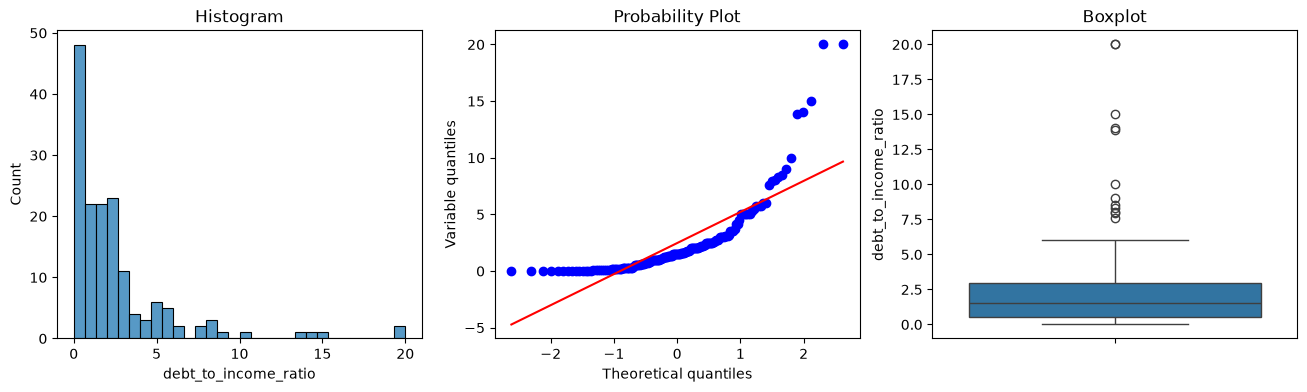

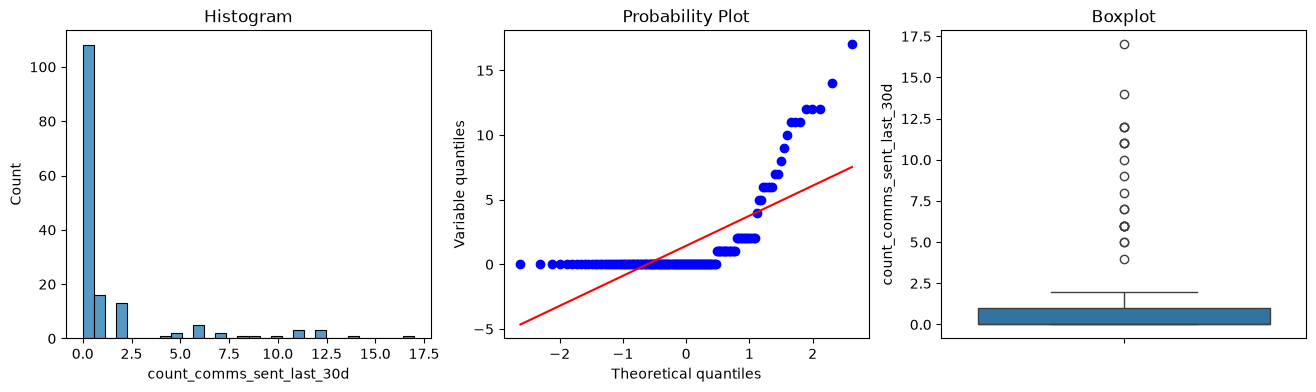

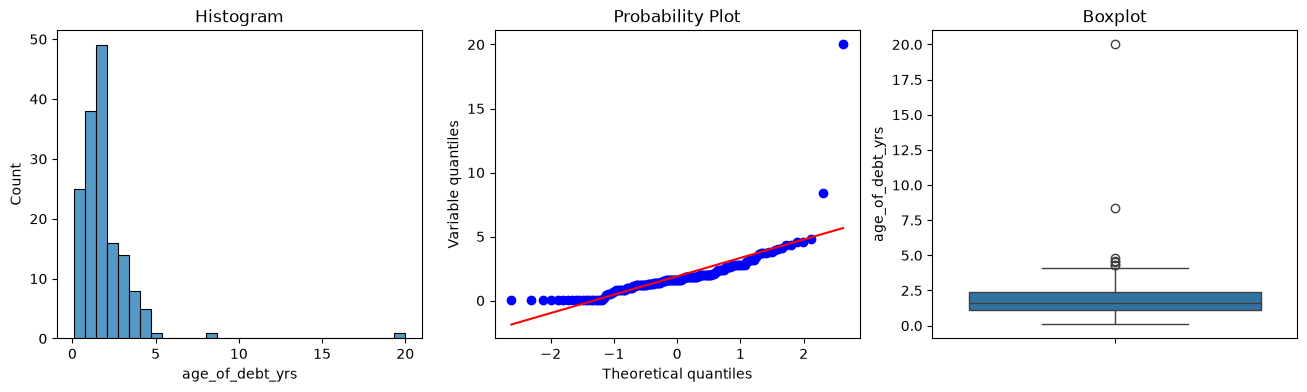

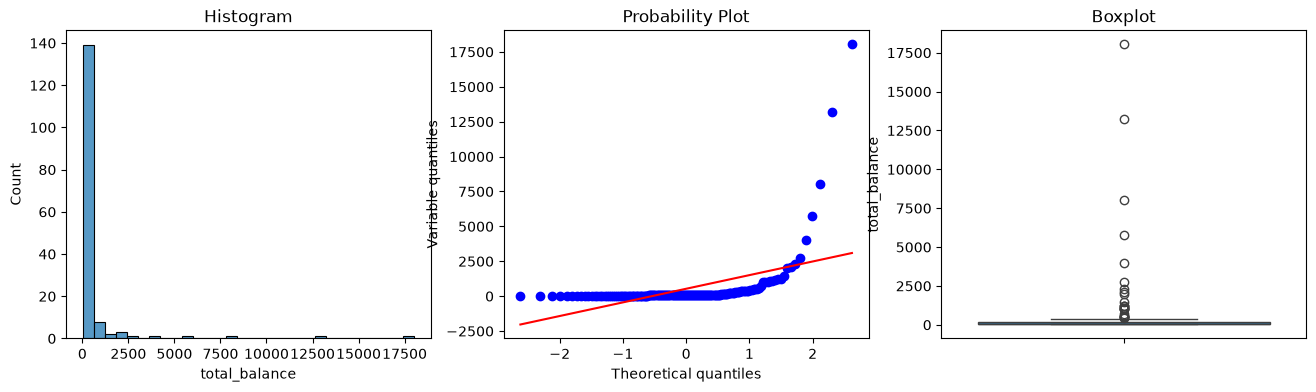

In [123]:
def diagnostic_per_product(df, product):
    data = df.copy()
    data = data[data['product'] == product]
    data = data[not_categorical].drop(not_for_corr, axis=1)

    for i in data.columns:
        diagnostic_plots(data, i)

for product in df['product'].unique():

    print(f"Diagnostic plots for product: {product}")

    diagnostic_per_product(df, product)

    plt.show()

# Testing behavoir of data depending on type of pruduct

Now, it's not enough to study data by only watching the plots since we can have a bad perception. Then, it's a good idea to use non-parametric tests, in this case we will use kolmogorov-smirnov test to check whether the data changes when the kind of product varies

In [4]:
# Since we are interested in a general case, it's important to consider not only the cases where product is only made up of
# Deferred Repayment and Credit Card. With the following function we will consider the cases when product could have more cases

#As we can see, this is a recursive function which is going to retrieve a list of combinations of the elements of a list

def combination(lista):
    if not lista:
        return [[]] # our base case when the list does not have more elements

    restantes = combination(lista[1:]) # recurisivity over the elements of the list save the first one
    resultados = [element + [lista[0]] for element in restantes] # adding the first element of the list to ones of restantes

    return restantes + resultados # we finally get the the combinations

print(combination(['a', 'b']))



[[], ['b'], ['a'], ['b', 'a']]


Now, it's important to notice that if we consider more than two elements, then this function will retreive more elements with many combinations. Fortunately that does not make our function useless. Let's now create our function ks_test_product where we will use our last function "combination" and we will only take those combinations made up of two elements

In [405]:
# First let's do some unit tests to our function to prove that it works as we expect
import itertools
import pytest

def test_empty_set():
    assert combination([]) == [[]]


def test_unique_element():
    assert combination(["a"]) == [[], ["a"]]


def test_two_elements():

    assert combination(["a", "b"]) == [[], ["b"], ["a"], ["b", "a"]]

test_empty_set()

test_unique_element()

test_two_elements()

# This cell runs well without any problem meaning that the unit test was successfulll

In [ ]:
# In order to guarantee that the information is consistent, we need to check whether 
# the behavior of the variables changes depending on the product.
# To test this, we can use Kolmogorov-Smirnov test, 
# which is a non-parametric test that can be used to compare two independent samples.


def ks_test_product(df, variable):

    data = df.copy()

    combination_products = combination(data['product'].unique())
    combination_products = [x for x in combination_products if len(x) == 2]

    # Notice that our function "combination" is very useful since it allows us to take the combinations that we want
    # Now let's compare how the variables behave when we take cases by type of product

    for products in combination_products:
        data_product_1 = data[data['product'] == products[0]][variable]
        data_product_2 = data[data['product'] == products[1]][variable]
        print(f"KS test for variable '{variable}' between products '{products[0]}' and '{products[1]}':")

        ks_statistic, p_value = ks_2samp(data_product_1, data_product_2)

        if p_value < 0.05:
            
            print("Reject null hypothesis: The distributions are different.")
            print(f'p-value < 0.05: {p_value:.4f}')

        else:
            print("Fail to reject null hypothesis: The distributions are the same.")
            print(f'p-value >= 0.05: {p_value:.4f}')

# Interpretation:
# the Kolmogorv-Smirnov thest allows us to check whether to disttributions are statistical different, to do so we study the p-value
# if the p-value < 0.05 then reject the null hypothesis meaning that the distributions are dfferent.
# if the p-value >= 0.05 then we fail to reject the null hypothesis and we say that there is not enough evidence to
# conclude that the distributions are different


In [ ]:
# Let's test only our numerical data (not binary). For the categorical data we will use other test
continuous_data = df[not_categorical].drop(not_for_corr, axis=1).columns



for column in continuous_data:
    ks_test_product(df, column)
    print()

KS test for variable 'minimum_payment' between products 'Deferred Repayment' and 'Credit Card':
Fail to reject null hypothesis: The distributions are the same.
p-value >= 0.05: 0.0588

KS test for variable 'previous_payment_amount' between products 'Deferred Repayment' and 'Credit Card':
Reject null hypothesis: The distributions are different.
p-value < 0.05: 0.0466

KS test for variable 'last_reminder_sent_days' between products 'Deferred Repayment' and 'Credit Card':
Fail to reject null hypothesis: The distributions are the same.
p-value >= 0.05: 0.1442

KS test for variable 'debt_to_income_ratio' between products 'Deferred Repayment' and 'Credit Card':
Reject null hypothesis: The distributions are different.
p-value < 0.05: 0.0005

KS test for variable 'count_comms_sent_last_30d' between products 'Deferred Repayment' and 'Credit Card':
Reject null hypothesis: The distributions are different.
p-value < 0.05: 0.0090

KS test for variable 'age_of_debt_yrs' between products 'Deferred Re

# This is a great discovery: 
it seems that the data behavior changes depending on the kind of product, except for minimum_payment and last_reminder_sent_days. This might suggest that it'be worthy to think in models for each product instead of a model blended

# Chi2
To study the relationship between categorical variables and the target variable we will use the Chi2 test which will tell us whether there is statistical dependency between the target and the categorical-input variables

In [ ]:
# we take only use a dataframe made up categorical variables

categorical_df = df[categorical_data + not_for_corr].drop('made_last_payment_on_time', axis=1).copy()
for i in categorical_df.columns:
    categorical_df[i] = categorical_df[i].astype(str)
chi_ls = []

for feature in categorical_df.columns:
    
    # create contingency table
    c = pd.crosstab(df['made_last_payment_on_time'], categorical_df[feature])
    
    # chi_test
    p_value = chi2_contingency(c)[1]
    chi_ls.append(p_value)

Text(0.5, 1.0, 'Feature importance based on chi-square test')

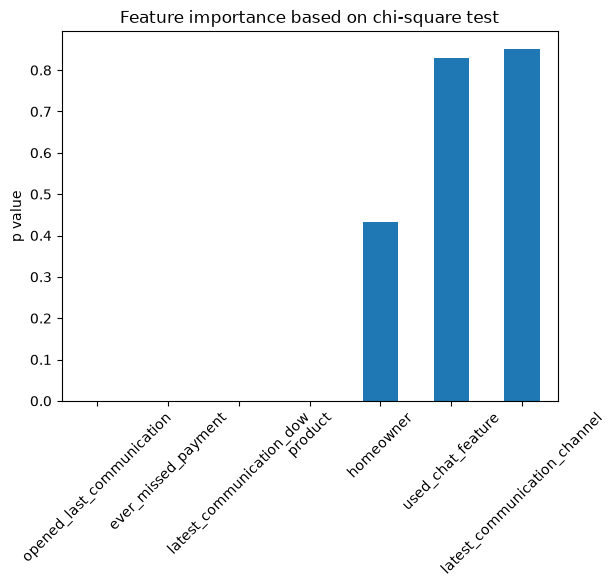

In [158]:
pd.Series(chi_ls, index=categorical_df.columns).sort_values(ascending=True).plot.bar(rot=45)
plt.ylabel('p value')
plt.title('Feature importance based on chi-square test')

# Interpretation:

The Chi2 test tells us whether the input variables and the target show dependency. When the p-value < 0.05 then we reject the null hypothesis, concluding there is a significant association. As we can see according to this test, the most strong variables are opened_last_communication_ ever_missed_payment, latest_communication_dow and product.

In [ ]:
# select top 4

selected = pd.Series(chi_ls, index=categorical_df.columns).sort_values(
    ascending=True)[0:4].index

selected

Index(['opened_last_communication', 'ever_missed_payment',
       'latest_communication_dow', 'product'],
      dtype='str')

# Feature Engineering for categorical data and Feature Selection


In [ ]:
# let's separate into training and testing set in order to avoid overfitting

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('made_last_payment_on_time', axis=1),  # predictors
    df['made_last_payment_on_time'],  # target
    test_size=0.2,  # percentage of obs in test set
    random_state=0,
)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((536, 14), (135, 14))

## Weight of Evidence (WoE) for converting categorical variables
Now let's apply feature engineering techniques. One of the most sucessfull methods to transform the categorical variables into numerical is WOE:

For each category $i$ of a categorical variable:

$$
\text{WoE}_i \;=\; \ln\!\left(\frac{\%\,\text{Distribution of goods}_i}{\%\,\text{Distribution of bads}_i}\right)

$$


In [407]:
# There is a library named feature-engine which allows us to use this techniques very eassilly:

woe_enc = WOEEncoder(cols=categorical_data)

In [409]:
woe_enc.fit(X_train, y_train)

,cols,"['latest_communication_channel', 'product', ...]"
,verbose,0
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None
,randomized,False
,sigma,0.05
,regularization,1.0
Name,Type,Value


In [410]:
# This is how the mapping is done. Don't pay attention to the -1 and -2 keys they are not part of the transformations

woe_enc.mapping

{'latest_communication_channel': latest_communication_channel
  1   -0.022796
  2    0.046637
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'product': product
  1    0.217755
  2   -0.691885
 -1    0.000000
 -2    0.000000
 dtype: float64,
 'latest_communication_dow': latest_communication_dow
  1    0.775318
  2   -0.108435
  3   -0.139262
  4   -1.435700
  5    0.484892
 -1    0.000000
 -2    0.000000
 dtype: float64}

In [185]:
X_train = woe_enc.transform(X_train)
X_test = woe_enc.transform(X_test)

# let's explore the result
X_train.head()

,latest_communication_channel,minimum_payment,previous_payment_amount,product,last_reminder_sent_days,debt_to_income_ratio,opened_last_communication,used_chat_feature,count_comms_sent_last_30d,homeowner,ever_missed_payment,age_of_debt_yrs,total_balance,latest_communication_dow
519,-0.022796,30.0,16.00,0.217755,8,3.00,1,1,0,0,1,2.40,101.00,0.775318
315,-0.022796,37.0,1.17,-0.691885,6,0.75,1,1,2,1,0,3.20,71.95,-0.108435
140,0.046637,16.0,8.00,0.217755,10,3.50,0,0,0,0,1,1.08,99.00,-0.108435
231,-0.022796,48.0,4.00,0.217755,7,0.00,1,1,7,0,1,1.10,94.82,-0.108435
526,0.046637,23.0,42.00,0.217755,9,2.00,0,0,0,0,0,1.44,44.48,-0.108435


In [ ]:
# In order to remember how the transformation took place, let's print the categories and their transformations
def woe_table(enc):
    out = {}
    for entry in enc.ordinal_encoder.mapping:
        col = entry['col']
        ordinal = entry['mapping']
        woe = enc.mapping[col] 

        t = pd.DataFrame({
            'category': ordinal.index,
            'key': ordinal.values,
        })
        t['woe'] = t['key'].map(woe)
        out[col] = t.sort_values('woe')
    return out

maps = woe_table(woe_enc)

for col, t in maps.items():
    print(f'{col}:')
    print(t.to_string(index=False))
    print()

latest_communication_channel:
category  key       woe
   Email    1 -0.022796
     NaN   -2  0.000000
     SMS    2  0.046637

product:
          category  key       woe
Deferred Repayment    2 -0.691885
               NaN   -2  0.000000
       Credit Card    1  0.217755

latest_communication_dow:
 category  key       woe
 Thursday    4 -1.435700
Wednesday    3 -0.139262
   Monday    2 -0.108435
      NaN   -2  0.000000
   Friday    5  0.484892
  Tuesday    1  0.775318



# Let's check whether tha data is balanced or unbalanced

One of the most important parts of building a classifier is checking whether our target variable is balanced or unbalanced since this can introduce noise to the model

made_last_payment_on_time
0    373
1    298
Name: count, dtype: int64


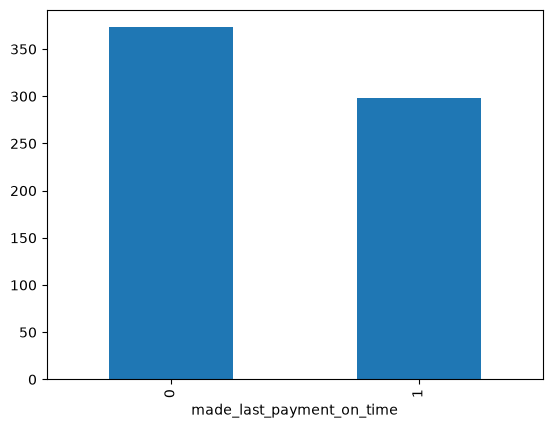

In [ ]:
# As we can see, our dataset is only a little unbalanced, then probably we can manage this by trying to get a good threshold for
# the classification

df['made_last_payment_on_time'].value_counts().plot(kind='bar')
print(df['made_last_payment_on_time'].value_counts())

# Feature Selection: Permutation Importance
The algorithm of permutation importance is one of the most powerfull and reliables methods to discover which variables are the most important when trying to predict the target. The background is to change the values of the input variables and check how much little changes affect the prediction: if litlle changes affect the prediction a lot then this variable is very important otherwise the input variable is considered weak.


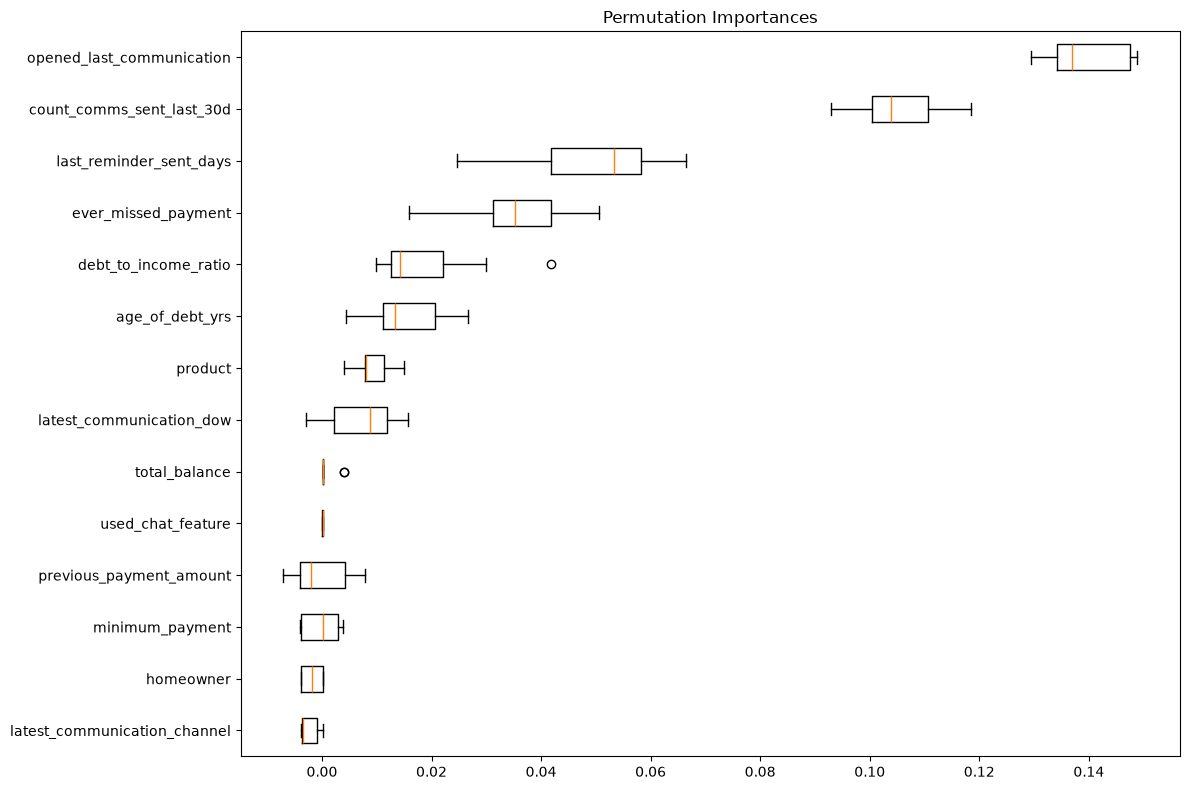

In [ ]:
### Pipeline for Feature-Selection. We will use LogisticRegresion as baseline since we have very few data

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from feature_engine.imputation import MeanMedianImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


#We'll use standarscaler for scaling
scaler = StandardScaler()

rf = Pipeline([
               ('Scaler', scaler),
               ('LogReg', LogisticRegression(random_state=0))])

rf.fit(X_train, y_train)

#Permutation Importance

from sklearn.inspection import permutation_importance
result = permutation_importance(rf, X_train, y_train, n_repeats=10,
                                random_state=42, n_jobs=1, scoring='precision')
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(12,8))
ax.boxplot(result.importances[sorted_idx].T,
           orientation='horizontal', tick_labels=X_train.columns[sorted_idx])
ax.set_title("Permutation Importances")
fig.tight_layout()
plt.show()

As we can see, for permutation importance, the most important variables are opened_last_communication, count_comms_sent_last_30d, last_reminder_sent_days and just a little ever_missed_payment.

# Recursive Feature Elimination

This is probably the best method to select input variables. This method is going to check the variance given for each variable and how much it affects the prediction. This method is the greatest because it's going to tell us the number of variables we need and which ones we need.

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


>2 0.807 (0.084)
>3 0.832 (0.060)


[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.1s remaining:    0.2s


>4 0.882 (0.052)


[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s


>5 0.918 (0.044)
>6 0.921 (0.039)


[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


>7 0.924 (0.029)
>8 0.929 (0.023)


[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining: 

>9 0.929 (0.031)
>10 0.941 (0.038)
>11 0.937 (0.039)


[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.0s finished


>12 0.933 (0.038)
>13 0.933 (0.043)


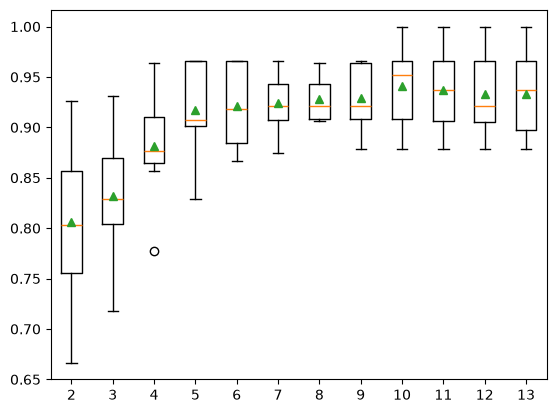

In [213]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, KFold
from numpy import mean
from numpy import std
from matplotlib import pyplot

# get a list of models to evaluate
def get_models():
    models = dict()
    for i in range(2,X_train.shape[1]):
        rfe = RFE(estimator=LogisticRegression(
                               random_state=0), n_features_to_select=i)
        model = LogisticRegression(
                               random_state=0)
        models[str(i)] = Pipeline([
               ('Scaler', scaler),
                ('s',rfe),
               ('m', model)])


    return models

# evaluate a give model using cross-validation
def evaluate_model(model, P, p):
    # We will focus on improving balanced_accuracy metric
    cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=0)
    scores = cross_val_score(model, P, p, scoring='precision', cv=cv, n_jobs=-1,
                             error_score='raise', verbose=5)
    return scores


# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
    scores = evaluate_model(model, X_train, y_train)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, tick_labels=names, showmeans=True)
pyplot.show()

# Interpretation:
Each boxplot tells us the score that each number of variables gets: the higher the orange line the better the score is. But there's something to consider: the larger the whiskers of the boxplots the larger it will be the variance, then more noise. According to this plot, the best choice is 10 variables to take. Now, let's  find out which variables are

In [ ]:
# With this piece of code we will find out the best 10 variables

rfe = RFE(estimator=LogisticRegression(random_state=0), n_features_to_select=10)
Rfe = Pipeline(steps=[
               ('Scaler', scaler),
               ('s',rfe)])

# fit RFE
Rfe.fit(X_train, y_train)
# summarize all features
seleccionadas = []
for i in range(X_train.shape[1]):
  if Rfe.named_steps['s'].support_[i]:
    seleccionadas.append(X_train.columns[i])
  print('Column: %d, Selected %s, Rank: %.3f' % (i, rfe.support_[i], rfe.ranking_[i]))

Column: 0, Selected False, Rank: 4.000
Column: 1, Selected False, Rank: 2.000
Column: 2, Selected True, Rank: 1.000
Column: 3, Selected True, Rank: 1.000
Column: 4, Selected True, Rank: 1.000
Column: 5, Selected True, Rank: 1.000
Column: 6, Selected True, Rank: 1.000
Column: 7, Selected False, Rank: 5.000
Column: 8, Selected True, Rank: 1.000
Column: 9, Selected False, Rank: 3.000
Column: 10, Selected True, Rank: 1.000
Column: 11, Selected True, Rank: 1.000
Column: 12, Selected True, Rank: 1.000
Column: 13, Selected True, Rank: 1.000


In [ ]:
seleccionadas

# Our final selection are these variables, according to RFE

['previous_payment_amount',
 'product',
 'last_reminder_sent_days',
 'debt_to_income_ratio',
 'opened_last_communication',
 'count_comms_sent_last_30d',
 'ever_missed_payment',
 'age_of_debt_yrs',
 'total_balance',
 'latest_communication_dow']

In [ ]:
# Let's then only work with these 10 variables as input

X_to_train = X_train[seleccionadas].copy()
X_to_test = X_test[seleccionadas].copy()

# Training time!

There is sometging we have in mind while developing our model: we have very few data, then the model we will use must not be a complex one. Let's remember that the purpose of building a model is not only getting good metrics in the test set, but also we must avoid overfitting and using a complex model for very few data can be dangerous. Then, let's start with a simple logistic regression.

Note: it's important to focus our developing of our model to either precision, recall or f1. To decide this we can ask:

"What does it hurt the most, predicting that someone is going to make the payment but at the end they don't make it or predicting that they are not going to make the payment but at the end they make it?"

Since the first option hurts the most, our developing will be focused on the precision metric.

In [430]:
# We start with a logistic regression without setting any hyperparameter but the random state
rf_p = Pipeline([
               ('Scaler', scaler),
               ('LogReg', LogisticRegression(random_state=0))])

rf_p.fit(X_to_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Scaler', ...), ('LogReg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['previous_payment_amount','product','last_reminder_sent_days',..., 'age_of_debt_yrs','total_balance','latest_communication_dow']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


ROC-AUC : 0.983
PR-AUC  : 0.981


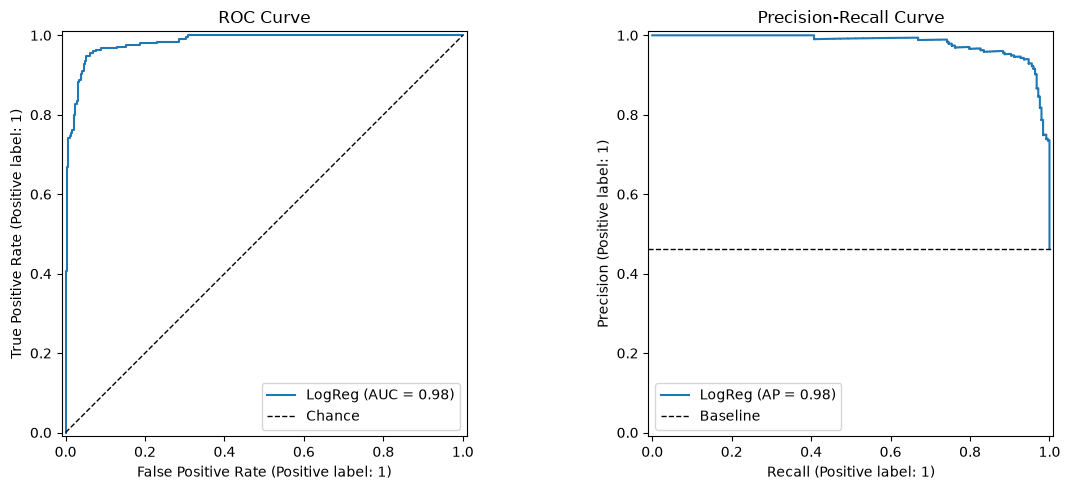

In [ ]:
# In order to choose a good threshold for classification we need to study both the ROC-AUC curve and the precision-recall curve
# It's good to remember that this must be done using the training data

from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                             roc_auc_score, average_precision_score)

y_score = rf_p.predict_proba(X_to_train)[:, 1]

print('ROC-AUC : %.3f' % roc_auc_score(y_train, y_score))
print('PR-AUC  : %.3f' % average_precision_score(y_train, y_score))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_predictions(y_train, y_score, name='LogReg', ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Chance')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_train, y_score, name='LogReg', ax=axes[1])
axes[1].axhline(y_train.mean(), color='k', ls='--', lw=1, label='Baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

fig.tight_layout()
plt.show()

As we can the curves are pretty uniform, that was expected since our dataset is not so unbalanced, but we need a method to get the best threshold, we will do that in the following lines

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve
# In order to get the best possible threshold using the precision-recall curve, we will use the method of the F1 to get that value
# This method is duitable since it considers unbalanced and balanced data


prec, rec, thr_pr = precision_recall_curve(y_train, y_score)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_f1_thr = thr_pr[f1s.argmax()]
print('Best threshold (F1)     : %.3f  -> P=%.3f R=%.3f F1=%.3f' % (
    best_f1_thr, prec[f1s.argmax()], rec[f1s.argmax()], f1s.max()))


Best threshold (F1)     : 0.441  -> P=0.940 R=0.948 F1=0.944


# Model Evaluation

In order to determine whether the model has a good performance we need to check the metrics for the training data, test data and checking whether there is a gap between them, if that's so then there is overfitting and that is something that we must avoid

              precision    recall  f1-score   support

           0      0.955     0.948     0.951       288
           1      0.940     0.948     0.944       248

    accuracy                          0.948       536
   macro avg      0.947     0.948     0.947       536
weighted avg      0.948     0.948     0.948       536



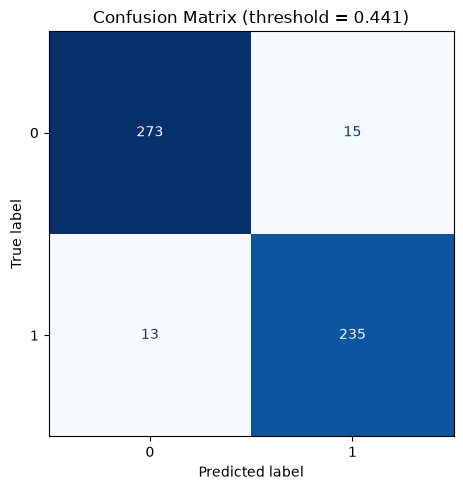

In [ ]:


from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_train = rf_p.predict_proba(X_to_train)[:, 1]
y_pred = np.where(y_score_train >= best_f1_thr, rf_p.classes_[1], rf_p.classes_[0])
print(classification_report(y_train, y_pred, digits=3))


cm = confusion_matrix(y_train, y_pred, labels=rf_p.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_p.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0      0.929     0.929     0.929        85
           1      0.880     0.880     0.880        50

    accuracy                          0.911       135
   macro avg      0.905     0.905     0.905       135
weighted avg      0.911     0.911     0.911       135



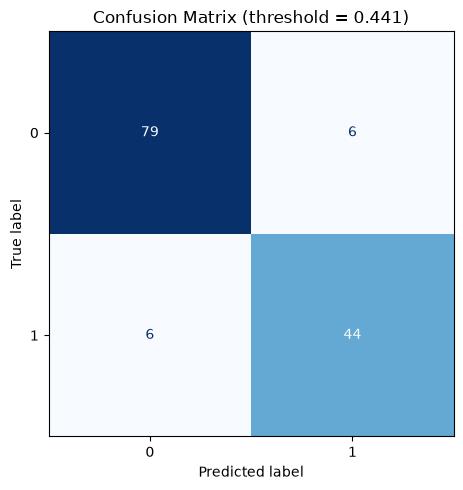

In [ ]:
bfrom sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_train = rf_p.predict_proba(X_to_test)[:, 1]
y_pred = np.where(y_score_train >= best_f1_thr, rf_p.classes_[1], rf_p.classes_[0])
print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred, labels=rf_p.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_p.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

We can see that our metrics have a good start:

train_precision: 0.940

test_precision: 0.880

train_recall: 0.948

test_recall: 0.880

this is something good since our main target is the metric precision which has a very amazing performance on the test data. But let's notice that the overfitting is very low too: aroung 6%, which is something that we want. Let's see if we can improve that using cross validation:

In [ ]:
#### Cross Validation to improve our technique
from sklearn.model_selection import RandomizedSearchCV

# We use StratifiedKFold to ensure each fold maintains the same proportion of target classes 
cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=100)

C = np.logspace(-3, 2, 20)  #inverse of regularization strength
penalty = ['l1', 'l2'] #type of regularization
solver = ['liblinear', 'saga'] # solver linear or for improving l1
class_weight = [None, 'balanced'] # to balance classes

random_grid = {'LogReg__C': C,

'LogReg__penalty': penalty,

'LogReg__solver': solver,

'LogReg__class_weight': class_weight,

'LogReg__max_iter': [500, 600, 700, 1000]
              }

# Let's use RandomizedSearch
gbm_random = RandomizedSearchCV(estimator = rf_p,

param_distributions = random_grid,
               n_iter = 40, cv = cv, verbose=2, random_state=0, n_jobs = -1,
               scoring="average_precision")

gbm_random.fit(X_train[seleccionadas], y_train)

#best estimator
best_model = gbm_random.best_estimator_

print('Best CV score (PR-AUC): %.3f' % gbm_random.best_score_)
print('Best model parameters \n' + str(best_model))

Fitting 8 folds for each of 40 candidates, totalling 320 fits
Best CV score (PR-AUC): 0.978
Best model parameters 
Pipeline(steps=[('Scaler', StandardScaler()),
                ('LogReg',
                 LogisticRegression(C=np.float64(0.12742749857031335),
                                    class_weight='balanced', max_iter=700,
                                    penalty='l2', random_state=0,
                                    solver='saga'))])


c:\Users\cleme\Documents\trueml_challenge\TrueML_Challenge\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [415]:
# Let's train again but now using the results of the cross validation

rf_p_cross = Pipeline([
               ('Scaler', scaler),
               ('LogReg', LogisticRegression(C=np.float64(0.12742749857031335),
                                    class_weight='balanced', max_iter=700,
                                    penalty='l2', random_state=0,
                                    solver='saga'))])

rf_p_cross.fit(X_to_train, y_train)

c:\Users\cleme\Documents\trueml_challenge\TrueML_Challenge\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Scaler', ...), ('LogReg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['previous_payment_amount','product','last_reminder_sent_days',..., 'age_of_debt_yrs','total_balance','latest_communication_dow']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


ROC-AUC : 0.982
PR-AUC  : 0.980


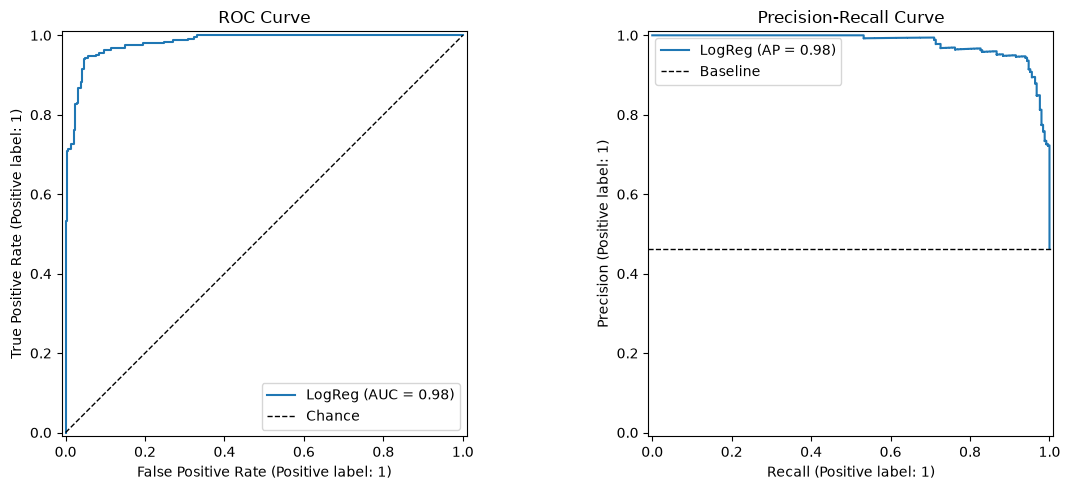

In [416]:
# we check the ROC-AUC curve and the precision-recall curve again


from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                             roc_auc_score, average_precision_score)

y_score_cross = rf_p_cross.predict_proba(X_to_train)[:, 1]

print('ROC-AUC : %.3f' % roc_auc_score(y_train, y_score_cross))
print('PR-AUC  : %.3f' % average_precision_score(y_train, y_score_cross))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_predictions(y_train, y_score_cross, name='LogReg', ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Chance')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_train, y_score_cross, name='LogReg', ax=axes[1])
axes[1].axhline(y_train.mean(), color='k', ls='--', lw=1, label='Baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

fig.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve

# We compute the best new threshold

prec, rec, thr_pr = precision_recall_curve(y_train, y_score_cross)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_f1_thr = thr_pr[f1s.argmax()]
print('Best threshold (F1)     : %.3f  -> P=%.3f R=%.3f F1=%.3f' % (
    best_f1_thr, prec[f1s.argmax()], rec[f1s.argmax()], f1s.max()))


Best threshold (F1)     : 0.525  -> P=0.944 R=0.944 F1=0.944


              precision    recall  f1-score   support

           0      0.951     0.951     0.951       288
           1      0.944     0.944     0.944       248

    accuracy                          0.948       536
   macro avg      0.947     0.947     0.947       536
weighted avg      0.948     0.948     0.948       536



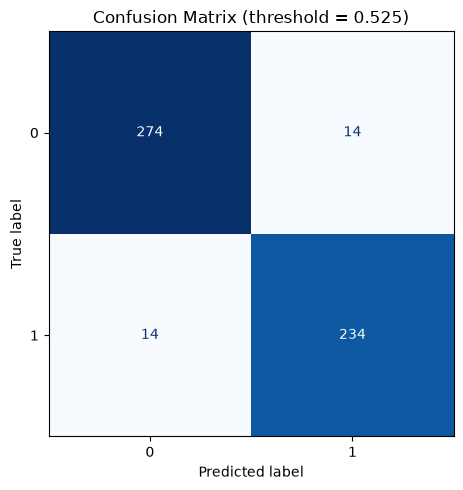

In [ ]:
# let's check the performance on the train data and test data

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_train = rf_p_cross.predict_proba(X_to_train)[:, 1]
y_pred = np.where(y_score_train >= best_f1_thr, rf_p_cross.classes_[1], rf_p_cross.classes_[0])
print(classification_report(y_train, y_pred, digits=3))


cm = confusion_matrix(y_train, y_pred, labels=rf_p_cross.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_p_cross.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0      0.929     0.929     0.929        85
           1      0.880     0.880     0.880        50

    accuracy                          0.911       135
   macro avg      0.905     0.905     0.905       135
weighted avg      0.911     0.911     0.911       135



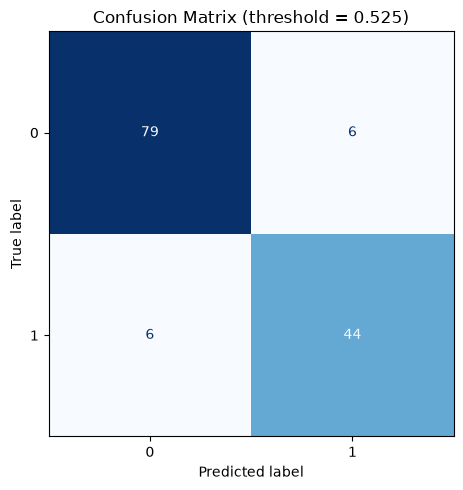

In [252]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_test = rf_p_cross.predict_proba(X_to_test)[:, 1]
y_pred = np.where(y_score_test >= best_f1_thr, rf_p_cross.classes_[1], rf_p_cross.classes_[0])
print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred, labels=rf_p_cross.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_p_cross.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

As we can see, the model did not improve after the cross validation. For now, our best model is a simple logistic regression 

# k-NN
As we recall, we are working with simple models since we have few data and since our logistic regression showed a little overfitting, let's try to reduce it by using a simpler model. If we use a more complex model the overfitting will increase. Then, our next attempt will be with a k-NN.

In [429]:
from sklearn.neighbors import KNeighborsClassifier
from feature_engine.outliers import Winsorizer

# Let's start with a simple k-NN aling with the scaler:

knn = KNeighborsClassifier()

knn_p = Pipeline([
               ('Scaler', scaler),
               ('knn', knn)])

knn_p.fit(X_to_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['previous_payment_amount','product','last_reminder_sent_days',..., 'age_of_debt_yrs','total_balance','latest_communication_dow']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


ROC-AUC : 0.988
PR-AUC  : 0.982


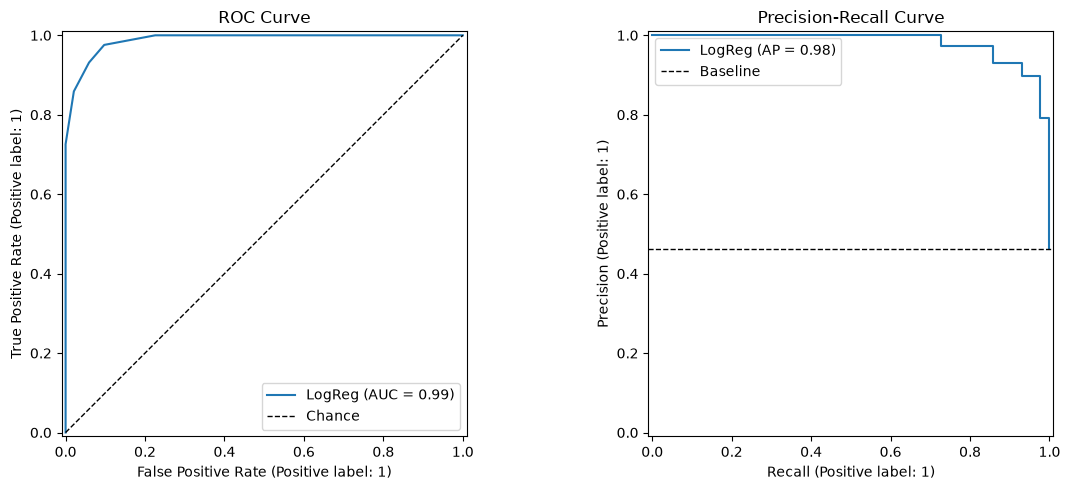

In [419]:
# Let's check our AUC-ROC and precision-recall curves

from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                             roc_auc_score, average_precision_score)

y_score = knn_p.predict_proba(X_to_train)[:, 1]

print('ROC-AUC : %.3f' % roc_auc_score(y_train, y_score))
print('PR-AUC  : %.3f' % average_precision_score(y_train, y_score))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_predictions(y_train, y_score, name='LogReg', ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Chance')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_train, y_score, name='LogReg', ax=axes[1])
axes[1].axhline(y_train.mean(), color='k', ls='--', lw=1, label='Baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

fig.tight_layout()
plt.show()

Again, the curves seem to be pretty uniform Let's get the best threshold

In [420]:
from sklearn.metrics import precision_recall_curve, roc_curve
# Let's  get the best threshold

prec, rec, thr_pr = precision_recall_curve(y_train, y_score)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_f1_thr = thr_pr[f1s.argmax()]
print('Best threshold (F1)     : %.3f  -> P=%.3f R=%.3f F1=%.3f' % (
    best_f1_thr, prec[f1s.argmax()], rec[f1s.argmax()], f1s.max()))

Best threshold (F1)     : 0.400  -> P=0.896 R=0.976 F1=0.934


              precision    recall  f1-score   support

           0      0.977     0.903     0.939       288
           1      0.896     0.976     0.934       248

    accuracy                          0.937       536
   macro avg      0.937     0.939     0.936       536
weighted avg      0.940     0.937     0.937       536



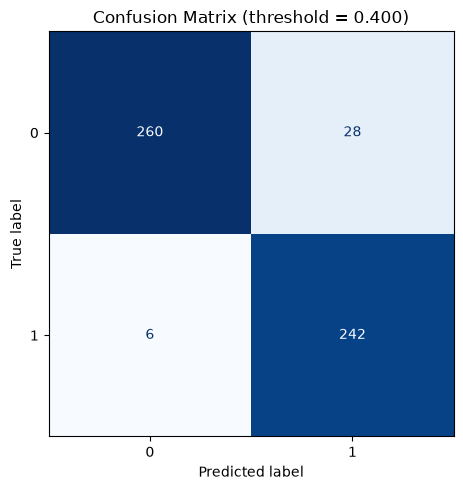

In [ ]:

# let's check the performance on the train data and test data

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_train = knn_p.predict_proba(X_to_train)[:, 1]
y_pred = np.where(y_score_train >= best_f1_thr, knn_p.classes_[1], knn_p.classes_[0])
print(classification_report(y_train, y_pred, digits=3))


cm = confusion_matrix(y_train, y_pred, labels=knn_p.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_p.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0      0.938     0.894     0.916        85
           1      0.833     0.900     0.865        50

    accuracy                          0.896       135
   macro avg      0.886     0.897     0.891       135
weighted avg      0.899     0.896     0.897       135



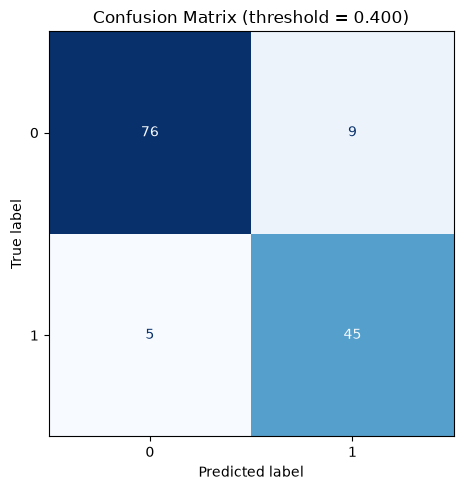

In [290]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_test = knn_p.predict_proba(X_to_test)[:, 1]
y_pred = np.where(y_score_test >= best_f1_thr, knn_p.classes_[1], knn_p.classes_[0])
print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred, labels=knn_p.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_p.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

We can see that our new model is not doing better however it keeps the gap of the overfitting the same: 6%, that is good but that our logistic regression is still the best model since it shows the same overfitting and it has better performance. Let's try to improve our k-NN as much as possible

In [ ]:
#### Cross Validation to improve our technique
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=100)

knn_p = Pipeline([
               ('Scaler', StandardScaler()),
               ('KNN', KNeighborsClassifier())])

n_neighbors = [int(x) for x in np.arange(1, 42, 2)]   # Number of neighbors
weights = ['uniform', 'distance']                     # Flat vote vs. distance-weighted vote
metric = ['euclidean', 'manhattan', 'minkowski']      # Distance metric
p = [1, 2, 3]                                         # Minkowski power (only used when metric='minkowski')

random_grid = {'KNN__n_neighbors': n_neighbors,

'KNN__weights': weights,

'KNN__metric': metric,

'KNN__p': p
              }

# Let's use RandomiedSearch
gbm_random = RandomizedSearchCV(estimator = knn_p,

param_distributions = random_grid,
               n_iter = 40, cv = cv, verbose=2, random_state=0, n_jobs = 1,
               scoring="average_precision")

gbm_random.fit(X_to_train, y_train)

#best estimator
best_model = gbm_random.best_estimator_

print('Best CV score (PR-AUC): %.3f' % gbm_random.best_score_)
print('Best model parameters \n' + str(best_model))

Fitting 8 folds for each of 40 candidates, totalling 320 fits
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=minkowski, KNN__n_neighbors=39, KNN__p=1, KNN__weights=uniform; total time=   0.0s
[CV] END KNN__metric=manhattan, KNN__n_neighbors=9, KNN__p=3, KNN__weights=distance; total time=   0.0s
[C

Since the number of neighbors is so high it's clear that this model will show a great overfitting, but let's see what we find

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Let's use the cross-validated-model:
knn_cross = KNeighborsClassifier(metric='manhattan', n_neighbors=31, p=3,
                                      weights='distance')

knn_p_cross = Pipeline([
               ('Scaler', scaler),
               ('knn', knn_cross)])

knn_p_cross.fit(X_to_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['previous_payment_amount','product','last_reminder_sent_days',..., 'age_of_debt_yrs','total_balance','latest_communication_dow']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


ROC-AUC : 1.000
PR-AUC  : 1.000


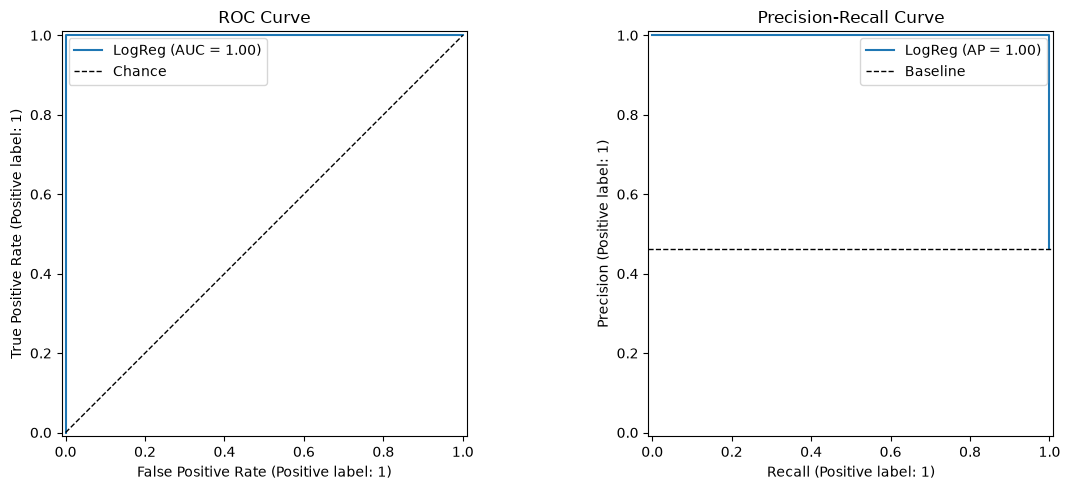

In [ ]:
# let's plot the AUC-ROC and precision-recall curves

from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                             roc_auc_score, average_precision_score)

y_score_cross = knn_p_cross.predict_proba(X_to_train)[:, 1]

print('ROC-AUC : %.3f' % roc_auc_score(y_train, y_score_cross))
print('PR-AUC  : %.3f' % average_precision_score(y_train, y_score_cross))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_predictions(y_train, y_score_cross, name='LogReg', ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Chance')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_train, y_score_cross, name='LogReg', ax=axes[1])
axes[1].axhline(y_train.mean(), color='k', ls='--', lw=1, label='Baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

fig.tight_layout()
plt.show()

As we expected, it's very clear in the plots that this model shows a lot of overfitting since it seems that the performance is "super amazing", then it's not a good idea to keep using it. 

# Let's try to improve the model by handiling outliers

As we saw in our first plots of the EDA, there are a lot of outliers that can be noise for our models, then let's try to handle them with some techniques, namely, we will use IQR to make capping of the outliers.

In [ ]:
# This plot is going to help us to check how well we capped the outliers by showing the boxplots and histograms
def plot_boxplot_and_hist(data, variable):
    
    plt.figure(figsize=(5, 3))
    # creating a figure composed of two matplotlib.Axes 
    # objects (ax_box and ax_hist)
    
    f, (ax_box, ax_hist) = plt.subplots(
        2, sharex=True, gridspec_kw={"height_ratios": (0.50, 0.85)}
    )

    # assigning a graph to each ax
    sns.boxplot(x=data[variable], ax=ax_box)
    sns.histplot(data=data, x=variable, ax=ax_hist)

    # Remove x axis name for the boxplot
    ax_box.set(xlabel="")
    plt.title(variable)
    plt.show()

In [422]:
# Since 'ever_missed_payment', 'opened_last_communication' are binary variables we can not apply outlier-handling on them
# in the other hand latest_communication_dow had troubles because of the  low values it has

seleccionadas_modified = [
    x for x in seleccionadas if x not in ['ever_missed_payment', 'latest_communication_dow', 'opened_last_communication']]

<Figure size 500x300 with 0 Axes>

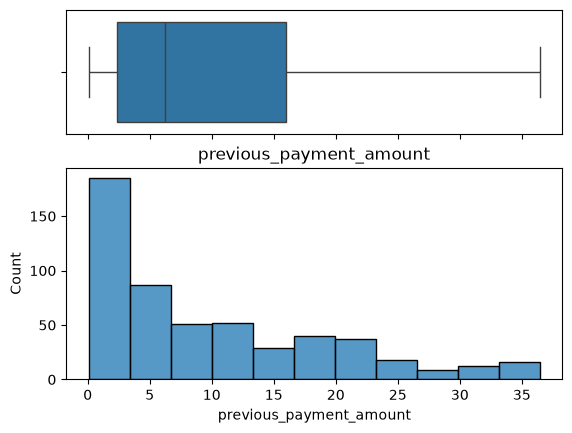

<Figure size 500x300 with 0 Axes>

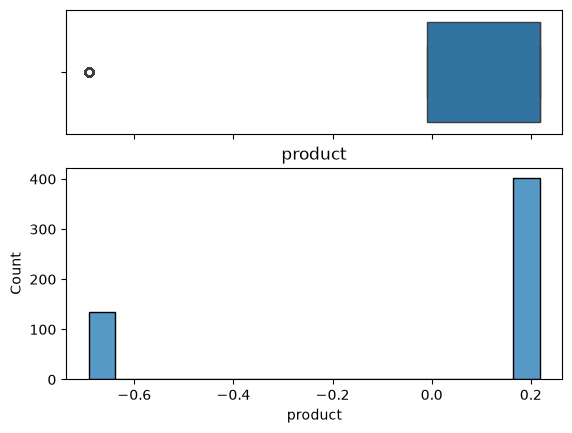

<Figure size 500x300 with 0 Axes>

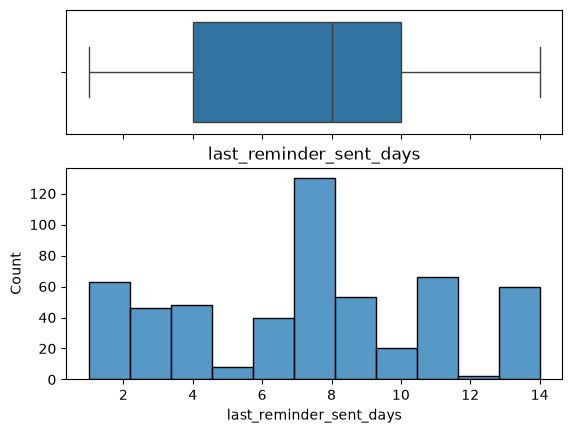

<Figure size 500x300 with 0 Axes>

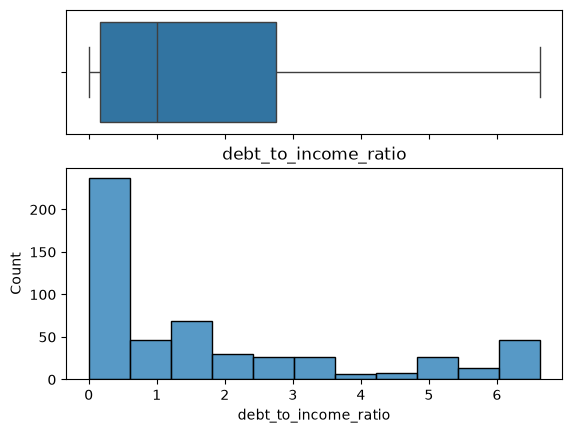

<Figure size 500x300 with 0 Axes>

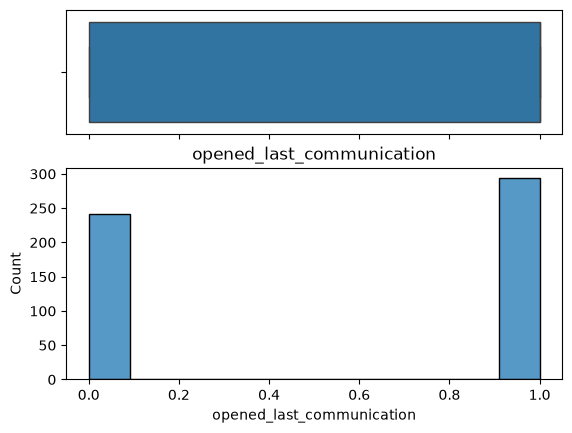

<Figure size 500x300 with 0 Axes>

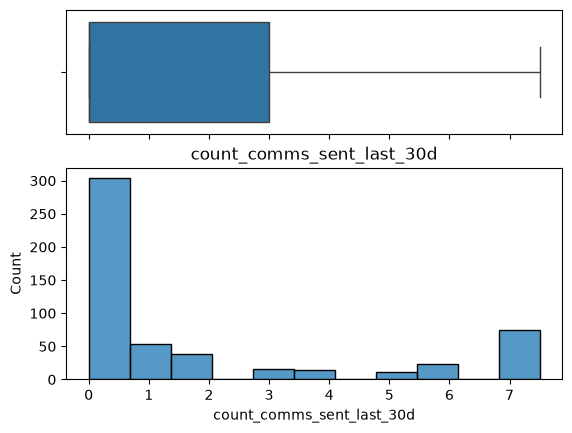

<Figure size 500x300 with 0 Axes>

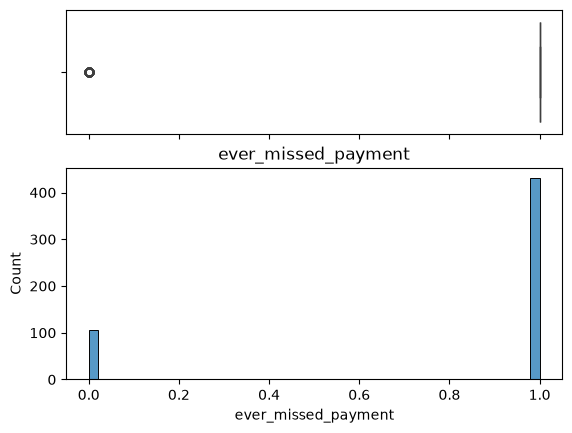

<Figure size 500x300 with 0 Axes>

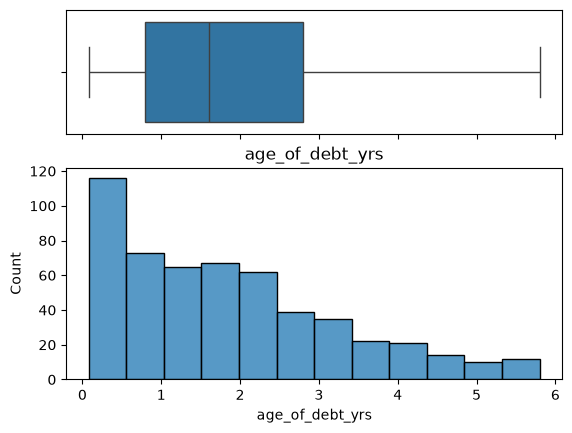

<Figure size 500x300 with 0 Axes>

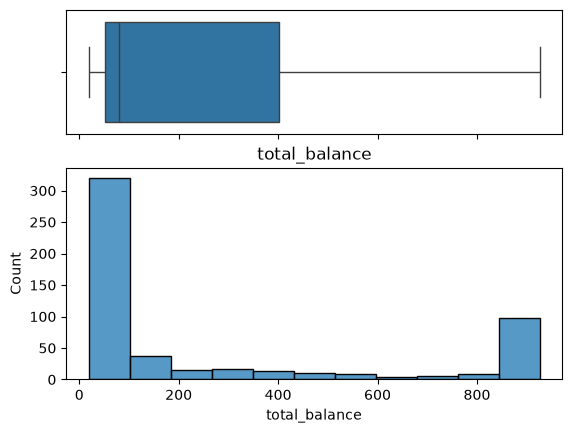

<Figure size 500x300 with 0 Axes>

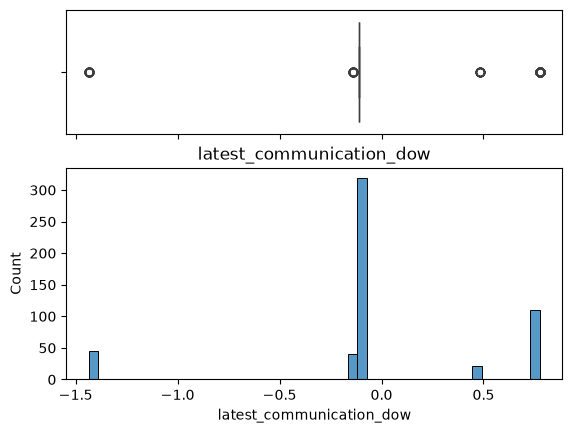

In [421]:
# Let's use the library of feature-engine and then use the method of IQR with a fold of 1.5 and since our data
# is skewed to the right, let's use the tail to the right
from feature_engine.outliers import Winsorizer


capper = Winsorizer(
    variables=seleccionadas_modified,
    capping_method="iqr",
    tail="right",
    fold=1.5,
)

capper.fit(X_to_train)

X_train_tr = capper.transform(X_to_train)
X_test_tr = capper.transform(X_to_test)

for column in X_train_tr:
    plot_boxplot_and_hist(X_train_tr, column)

In [434]:
# Let's see if our Logistic Regression can be improved or at least let's see if the overfitting can be reduced

knn = LogisticRegression()

knn_p = Pipeline([
               ('Scaler', scaler),
               ('knn', knn)])

knn_p.fit(X_train_tr, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['previous_payment_amount','product','last_reminder_sent_days',..., 'age_of_debt_yrs','total_balance','latest_communication_dow']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


ROC-AUC : 0.988
PR-AUC  : 0.987


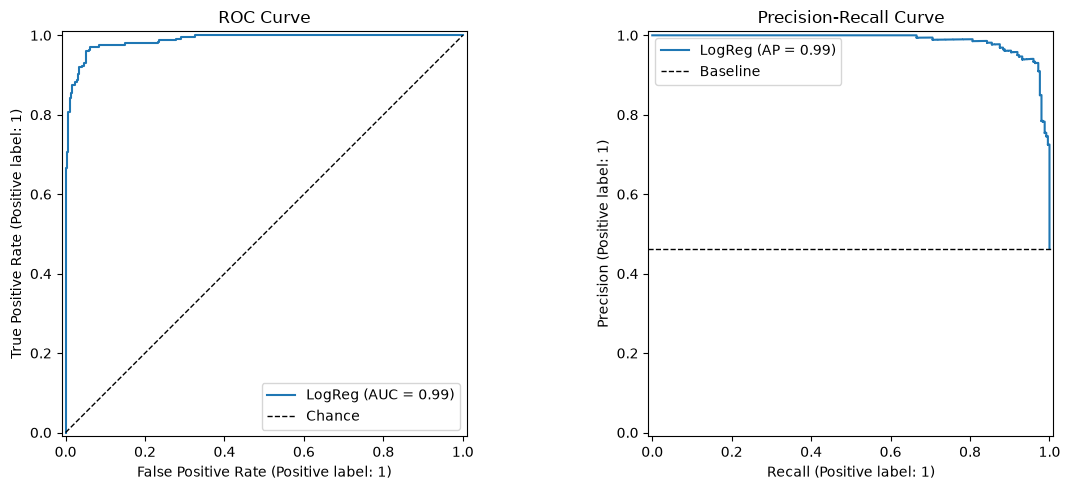

In [435]:
# Let's plot the AUC-ROC and precision-recall curves

from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                             roc_auc_score, average_precision_score)

y_score_cross = knn_p.predict_proba(X_train_tr)[:, 1]

print('ROC-AUC : %.3f' % roc_auc_score(y_train, y_score_cross))
print('PR-AUC  : %.3f' % average_precision_score(y_train, y_score_cross))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_predictions(y_train, y_score_cross, name='LogReg', ax=axes[0])
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Chance')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_train, y_score_cross, name='LogReg', ax=axes[1])
axes[1].axhline(y_train.mean(), color='k', ls='--', lw=1, label='Baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

fig.tight_layout()

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve
# Let's get our best threshold

prec, rec, thr_pr = precision_recall_curve(y_train, y_score_cross)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_f1_thr = thr_pr[f1s.argmax()]
print('Best threshold (F1)     : %.3f  -> P=%.3f R=%.3f F1=%.3f' % (
    best_f1_thr, prec[f1s.argmax()], rec[f1s.argmax()], f1s.max()))

Best threshold (F1)     : 0.366  -> P=0.931 R=0.972 F1=0.951


              precision    recall  f1-score   support

           0      0.975     0.938     0.956       288
           1      0.931     0.972     0.951       248

    accuracy                          0.953       536
   macro avg      0.953     0.955     0.953       536
weighted avg      0.954     0.953     0.953       536



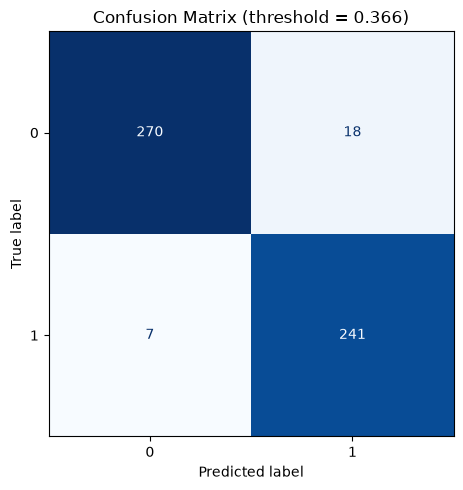

In [ ]:
# Let's take a look at the performance in train and test data

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_train = knn_p.predict_proba(X_train_tr)[:, 1]
y_pred = np.where(y_score_train >= best_f1_thr, knn_p.classes_[1], knn_p.classes_[0])
print(classification_report(y_train, y_pred, digits=3))


cm = confusion_matrix(y_train, y_pred, labels=knn_p.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_p.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0      0.940     0.918     0.929        85
           1      0.865     0.900     0.882        50

    accuracy                          0.911       135
   macro avg      0.903     0.909     0.905       135
weighted avg      0.912     0.911     0.911       135



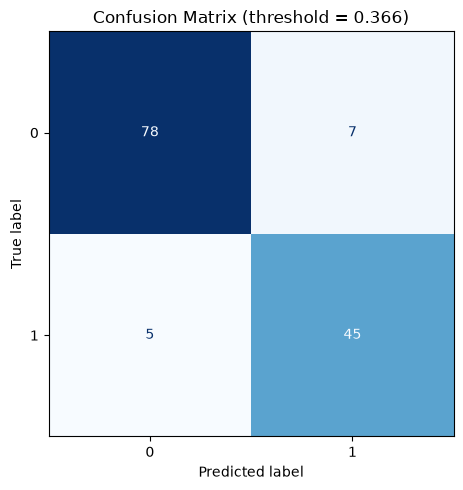

In [427]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_recall_fscore_support)

y_score_test = knn_p.predict_proba(X_test_tr)[:, 1]
y_pred = np.where(y_score_test >= best_f1_thr, knn_p.classes_[1], knn_p.classes_[0])
print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred, labels=knn_p.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_p.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

The result is clear, this model was not improved even capping the outliers. Then our champion model is a simple Logistic Regression

# SHAP

Now that we have our model champion let's interpret how the impact of each variable is by using SHAP

Background dataset has 536 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=536 when initializing the masker.


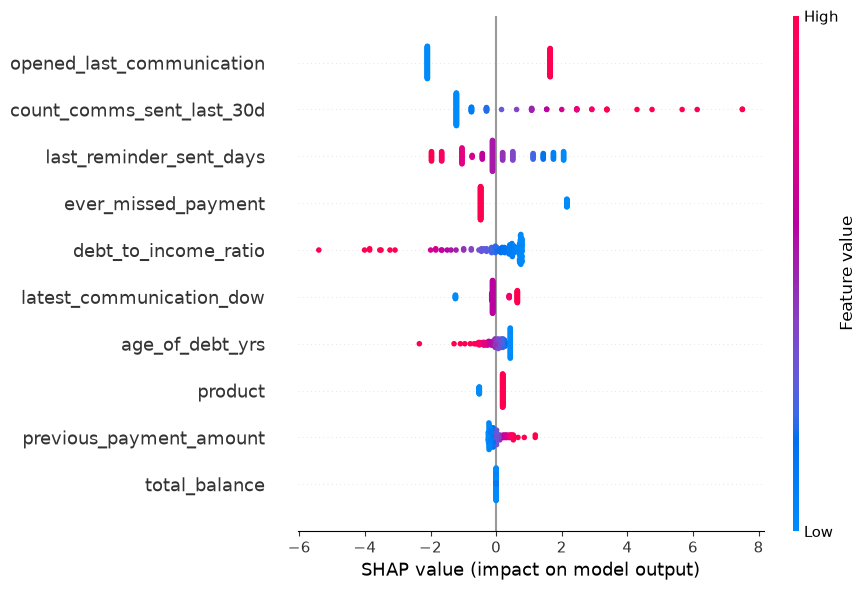

In [431]:
import shap
explainer = shap.LinearExplainer(rf_p.named_steps['LogReg'],
                                 rf_p.named_steps['Scaler'].transform(X_to_train),
                                 feature_names=list(X_to_train.columns))
shap_values = explainer(rf_p.named_steps['Scaler'].transform(X_to_test))

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6)
plt.tight_layout()
plt.show()

# Interpretation

In this SHAP plot, the more the value gets to the right side the more likely is that the prediction is postive, on the other hand, the more the value gets to the left side the more likely is that the prediction is negative. The redder the color is the higher the values of the variables are and the bluer the color is, the lower the values of the variables are.

1. `opened_last_communication`: it has an almost balanced effect, but lower values tend to lead the prediction a little bit more to be negative

2.  `count_comms_sent_last_30d`: This variable has more affect to the right (positive prediction) when number of comms increases

3. `last_reminder_sent_days`: it's a negative variable in general: the more days have passed since the last reminder the lower the probabilty is that the debter makes the payment. But it has a little effect on the contrary: the fewer days since last reminder the higher the probability is that the debter makes the payment

4. `debt_to_income_ratio`: a negative variable in general: the higher the debt-to-income ratio is the lower the probablity of making the payment is

5. `ever_missed_payment`: despite that this variable has a strong effect on the negative side, there is a postive effect: if the debter tends to not have missed payments then it's more likely that they make their next payment

6. `age_of_debt_yrs`: a negative variable: the more years the debter has with the debt the lower is the probability of making the payment

7. `previous_payment_amount`: it is a postive variable but with a weak effect: if the previous payment was made then it's more likly that the next payment is made too

8. `product`: as you can see in the table below, in the plot we can see that when people have a Credit Card the probability of making the payment increases but it's a weak effect. In the other hand Deferred Repayment tends to make the probability of payment less likely

9. `latest_communication_dow`: The effect is very weak to both sides, in general it does not provide important information

10. `total_balance`: This variable is completely weak since the effect on the prediction is almost zero.


# This is the table of category transformations to help us make the interpretation of the SHAP plot

### `product`

| Categoría | WoE |
|:---|---:|
| Deferred Repayment | −0.6919 |
| Credit Card | +0.2178 |

### `latest_communication_dow`

| Categoría | WoE |
|:---|---:|
| Thursday | −1.4357 |
| Wednesday | −0.1393 | 
| Monday | −0.1084 |
| Friday | +0.4849 |
| Tuesday | +0.7753 |

# MLflow to complement our project
It's important to keep track of the models we build, then one of the best practices is to use MLflow to track our experimentations. In the next lines of code there is some examples of how tracking of the models was made and how we chose our champion to launche it into production

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Let's create our path to sabe the mlflow.db
mlflow.set_tracking_uri("sqlite:///C:/Users/cleme/Documents/trueml_challenge/TrueML_Challenge/mlflow.db")
mlflow.set_experiment("trueml_challenge")

# In this example we can see how we saved the k-NN.
# Note: our champion was saved firts already

knn = KNeighborsClassifier()

knn_ml = Pipeline([
               ('Scaler', scaler),
               ('knn', knn)])



with mlflow.start_run(run_name="knn_not_cross"):

    knn_ml.fit(X_to_train, y_train)

    y_score_train = knn_ml.predict_proba(X_to_train)[:, 1]
    y_pred_train = np.where(y_score_train >= best_f1_thr,
                            knn_ml.classes_[1], knn_ml.classes_[0])

    y_score_test = knn_ml.predict_proba(X_to_test)[:, 1]
    y_pred_test = np.where(y_score_test >= best_f1_thr,
                           knn_ml.classes_[1], knn_ml.classes_[0])

    # Hyperparameters and features are saved 
    # Note that we are saving the decision threshold from train data, it's important to keep track of this number
    mlflow.log_params({f"knn__{k}": v for k, v in
                       knn_ml.named_steps['knn'].get_params().items()})
    mlflow.log_param("decision_threshold", float(best_f1_thr))
    mlflow.log_param("n_features", X_to_train.shape[1])
    mlflow.log_param("features", list(X_to_train.columns))

    # Metrics are saved
    for split, y_true, y_hat, y_prob in [("train", y_train, y_pred_train, y_score_train),
                                         ("test",  y_test,  y_pred_test,  y_score_test)]:
        p_pos, r_pos, f1_pos, _ = precision_recall_fscore_support(
            y_true, y_hat, average='binary', pos_label=knn_ml.classes_[1])
        mlflow.log_metrics({
            f"{split}_precision": p_pos,
            f"{split}_recall": r_pos,
            f"{split}_f1": f1_pos,
            f"{split}_roc_auc": roc_auc_score(y_true, y_prob),
            f"{split}_pr_auc": average_precision_score(y_true, y_prob),
        })

    # Model is saved
    mlflow.sklearn.log_model(
        knn_ml, name="knn_not_cross_trueml",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        signature=infer_signature(X_to_train.astype('float64'), y_score_train),
        input_example=X_to_train.head(5).astype('float64'))
    print(mlflow.active_run().info.run_id)

2026/08/22 18:43:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


659d790c48bf4e1bae3c99eab041b6a4


In [ ]:
# Let's have a look at this experimentation

run_id = "659d790c48bf4e1bae3c99eab041b6a4"

model = mlflow.sklearn.load_model(f"runs:/{run_id}/knn_not_cross_trueml")

# the threshold comes with the run, not with the model

run = mlflow.get_run(run_id)
thr = float(run.data.params["decision_threshold"])
features = eval(run.data.params["features"])   # se guardó como string de lista

# some example of predictions
X_nuevo = X_test[features]
y_prob = model.predict_proba(X_nuevo)[:, 1]
y_pred = np.where(y_prob >= thr, model.classes_[1], model.classes_[0])

              precision    recall  f1-score   support

           0      0.938     0.894     0.916        85
           1      0.833     0.900     0.865        50

    accuracy                          0.896       135
   macro avg      0.886     0.897     0.891       135
weighted avg      0.899     0.896     0.897       135



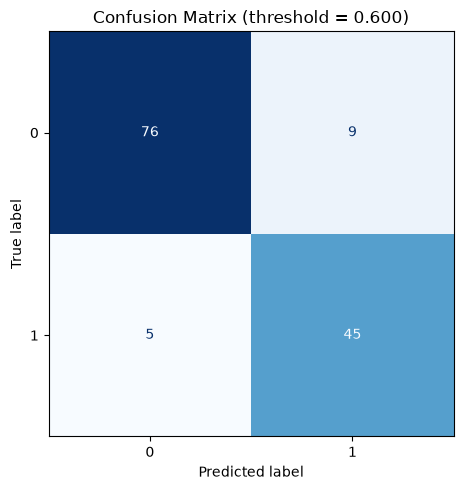

In [ ]:
# Let's have a look at the performance

print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

The last was an example of how to save one experimentation, in the following lines of code let's show how to deploy our model champion into production. Note: to make the choice we have to go to the MLflow web page (given to us once we install MLflow) and then compare metrics, then we choose our model.



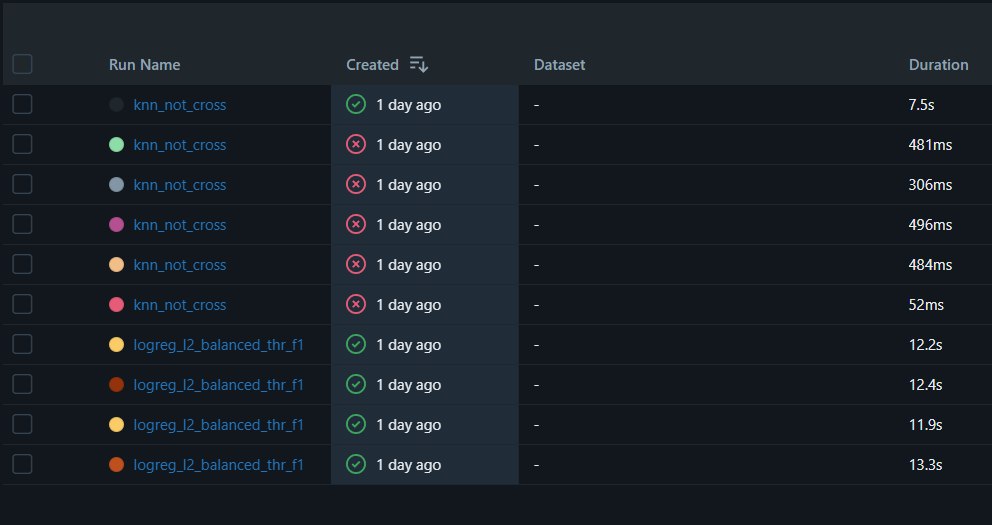

In [ ]:
from IPython.display import Image
Image("mlflow.png", width=600)

# Example of my MLflow page

In [ ]:
# Stage: Prod

from mlflow import MlflowClient

client = MlflowClient()
run_id = "626d2cf870c84b2b951398dbb02e8953"

# We registry our best model
mv = mlflow.register_model(f"runs:/{run_id}/model_trueml",
                           "trueml_collections_logr")
print("Versión registrada:", mv.version)

# Name it as champion
client.set_registered_model_alias("trueml_collections_logr", "champion_log", mv.version)

# we bring up the threshold 

run = client.get_run(run_id)
client.set_model_version_tag("trueml_collections_logr", mv.version,
                             "decision_threshold",
                             run.data.params["decision_threshold"])

Successfully registered model 'trueml_collections_logr'.
2026/08/23 12:54:44 WARNING mlflow.tracking._model_registry.fluent: Run with id 626d2cf870c84b2b951398dbb02e8953 has no artifacts at artifact path 'model_trueml', registering model based on models:/m-564f261fefb14bc89e4dea99d7204937 instead
Created version '1' of model 'trueml_collections_logr'.


Versión registrada: 1


In [ ]:
# now we can loead or champion model
model = mlflow.sklearn.load_model("models:/trueml_collections_logr@champion_log")

mv = client.get_model_version_by_alias("trueml_collections_logr", "champion_log")
thr = float(mv.tags["decision_threshold"])

y_prob = model.predict_proba(X_nuevo)[:, 1]
y_pred = np.where(y_prob >= thr, model.classes_[1], model.classes_[0])

              precision    recall  f1-score   support

           0      0.929     0.929     0.929        85
           1      0.880     0.880     0.880        50

    accuracy                          0.911       135
   macro avg      0.905     0.905     0.905       135
weighted avg      0.911     0.911     0.911       135



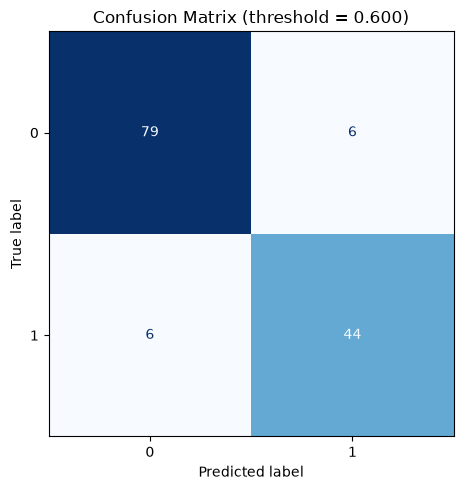

In [ ]:
# let's have a look at the performance of our champion

print(classification_report(y_test, y_pred, digits=3))


cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix (threshold = %.3f)" % best_f1_thr)
fig.tight_layout()
plt.show()

# Conclusions

There are several important things to point out:
Despite being an almost balanced dataset, we found some problems mitigate the overfitting, this was probably caused because of some noise in the data, then it would be worthy to consider other kind of transformations of the categorical and numerical data. Something that we have for sure is that a more complex model would not work since we have very few data, definitely the best model we can consider is a simple model, otherwise the overfitting would be strong and that makes the models not reliable.

There are more techniques for outliers-handling such as using quantiles, random capping and more, then probably we could try those techniques to improve the performance and mitigate overfitting.

Our best model was finally a simple logistic regression and it makes totally sense for the same reasons. Something that definitely could help to improve these results is to gather more data. Maybe we can try more techniques of feature engineering but it would be better to have more data available.
Despite that our model is not perfect, it does a great job since the overfitting is very small and the performance is acceptable.
Only to have in mind the last results of our champion are:

1. precision = 0.88
2. recall = 0.88
3. f1 = 0.88